In [1]:
# ============================================================
# Mount Google Drive
# ============================================================

from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
from pathlib import Path

PROJECT_DIR = Path(
    "/content/drive/MyDrive/TopicEvalBench"
)

MODEL_DIR = PROJECT_DIR /"models"

Part 6A — Load Results

In [3]:
# ============================================================
# 6A-1 Imports
# ============================================================

import numpy as np
import pandas as pd

from pathlib import Path

from scipy.stats import (
    spearmanr,
    pearsonr,
    kendalltau,
    wilcoxon
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import matplotlib.pyplot as plt

In [4]:
# ============================================================
# 6A-2 Paths
# ============================================================

ANALYSIS_DIR = MODEL_DIR / "analysis"

ANALYSIS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Analysis directory:")
print(ANALYSIS_DIR)

Analysis directory:
/content/drive/MyDrive/TopicEvalBench/models/analysis


Part 6B — Save Central Analysis Dataset

In [5]:
# ============================================================
# 6B-1 Load Central Experiment Manifest
# ============================================================

manifest_file = (
    MODEL_DIR /
    "experiment_manifest_stage4.csv"
)

manifest = pd.read_csv(
    manifest_file
)

print("Manifest shape:", manifest.shape)

display(
    manifest.head()
)

Manifest shape: (495, 42)


,ExperimentID,Fold,Topics,Status,TrainingDocuments,DictionarySize,RandomSeed,Passes,Iterations,Alpha,...,AbsCV,AbsUCI,AbsNPMI,NAC_UMass,NAC_CV,NAC_UCI,NAC_NPMI,MeanLogPerplexity,AbsLogPerplexity,NAP
0,F1_K002,1,2,Available,240,891,42,20,400,"[0.5, 0.5]",...,0.308302,4.338849,0.128971,0.911404,0.574189,0.720333,0.801366,-6.603739,6.603739,0.480608
1,F1_K003,1,3,Available,240,891,42,20,400,"[0.3333333432674408, 0.3333333432674408, 0.333...",...,0.382957,2.588816,0.045408,0.604294,0.713229,0.429793,0.282142,-6.728118,6.728118,0.489660
2,F1_K004,1,4,Available,240,891,42,20,400,"[0.25, 0.25, 0.25, 0.25]",...,0.442629,2.979363,0.055813,0.550564,0.824363,0.494632,0.346796,-6.848727,6.848727,0.498438
3,F1_K005,1,5,Available,240,891,42,20,400,"[0.20000000298023224, 0.20000000298023224, 0.2...",...,0.430353,2.637528,0.026696,0.567507,0.801500,0.437881,0.165874,-6.998321,6.998321,0.509325
4,F1_K006,1,6,Available,240,891,42,20,400,"[0.1666666716337204, 0.1666666716337204, 0.166...",...,0.462751,2.580816,0.021140,0.553058,0.861839,0.428465,0.131356,-7.142265,7.142265,0.519801


In [6]:
# ============================================================
# 6B-1A Load NAC and NAP Results
# ============================================================

nac_file = (
    MODEL_DIR /
    "NAC.csv"
)

nap_file = (
    MODEL_DIR /
    "NAP.csv"
)

nac_df = pd.read_csv(
    nac_file
)

nap_df = pd.read_csv(
    nap_file
)


print("\nNAC Fold counts:")

print(
    nac_df["Fold"]
    .value_counts()
    .sort_index()
)


print("\nNAP Fold counts:")

print(
    nap_df["Fold"]
    .value_counts()
    .sort_index()
)


print("NAC shape:", nac_df.shape)
print("NAP shape:", nap_df.shape)

print("\nNAC columns:")
print(nac_df.columns.tolist())

print("\nNAP columns:")
print(nap_df.columns.tolist())

display(nac_df.head())
display(nap_df.head())


NAC Fold counts:
Fold
1    99
2    99
3    99
4    99
5    99
Name: count, dtype: int64

NAP Fold counts:
Fold
1    99
2    99
3    99
4    99
5    99
Name: count, dtype: int64
NAC shape: (495, 15)
NAP shape: (495, 7)

NAC columns:
['ExperimentID', 'Fold', 'Topics', 'UMass', 'CV', 'UCI', 'NPMI', 'AbsUMass', 'AbsCV', 'AbsUCI', 'AbsNPMI', 'NAC_UMass', 'NAC_CV', 'NAC_UCI', 'NAC_NPMI']

NAP columns:
['ExperimentID', 'Fold', 'Topics', 'MeanLogPerplexity', 'PerplexityTest', 'AbsLogPerplexity', 'NAP']


,ExperimentID,Fold,Topics,UMass,CV,UCI,NPMI,AbsUMass,AbsCV,AbsUCI,AbsNPMI,NAC_UMass,NAC_CV,NAC_UCI,NAC_NPMI
0,F1_K002,1,2,-4.680316,0.308302,-4.338849,-0.128971,4.680316,0.308302,4.338849,0.128971,0.911404,0.574189,0.720333,0.801366
1,F1_K003,1,3,-3.103219,0.382957,-2.588816,-0.045408,3.103219,0.382957,2.588816,0.045408,0.604294,0.713229,0.429793,0.282142
2,F1_K004,1,4,-2.827298,0.442629,-2.979363,-0.055813,2.827298,0.442629,2.979363,0.055813,0.550564,0.824363,0.494632,0.346796
3,F1_K005,1,5,-2.914309,0.430353,-2.637528,-0.026696,2.914309,0.430353,2.637528,0.026696,0.567507,0.801500,0.437881,0.165874
4,F1_K006,1,6,-2.840108,0.462751,-2.580816,-0.021140,2.840108,0.462751,2.580816,0.021140,0.553058,0.861839,0.428465,0.131356


,ExperimentID,Fold,Topics,MeanLogPerplexity,PerplexityTest,AbsLogPerplexity,NAP
0,F1_K002,1,2,-6.603739,97.257601,6.603739,0.480608
1,F1_K003,1,3,-6.728118,106.014498,6.728118,0.489660
2,F1_K004,1,4,-6.848727,115.258289,6.848727,0.498438
3,F1_K005,1,5,-6.998321,127.851162,6.998321,0.509325
4,F1_K006,1,6,-7.142265,141.265426,7.142265,0.519801


In [7]:
# ============================================================
# 6B-2 Load Downstream Classification Results
# ============================================================
CLASSIFICATION_DIR = PROJECT_DIR /"classification"

logreg_results = pd.read_csv(
    CLASSIFICATION_DIR /
    "logistic_regression_results.csv"
)

rf_results = pd.read_csv(
    CLASSIFICATION_DIR /
    "random_forest_results.csv"
)

svm_results = pd.read_csv(
    CLASSIFICATION_DIR /
    "svm_results.csv"
)

print("Logistic Regression :", logreg_results.shape)
print("Random Forest       :", rf_results.shape)
print("SVM                 :", svm_results.shape)

Logistic Regression : (495, 9)
Random Forest       : (495, 9)
SVM                 : (495, 9)


In [ ]:
# ============================================================
# 6B-3 Build Central Analysis Dataset
# ============================================================

analysis_df = manifest.copy()

# ============================================================
# Remove old normalized metric columns if present
# ============================================================

old_normalized_columns = [

    "NAC",
    "NAP",

    "NAC_UMass",
    "NAC_CV",
    "NAC_UCI",
    "NAC_NPMI",

    "AbsUMass",
    "AbsCV",
    "AbsUCI",
    "AbsNPMI",

    "MeanLogPerplexity",
    "AbsLogPerplexity"
]

columns_to_drop = [

    column
    for column in old_normalized_columns
    if column in analysis_df.columns
]

if columns_to_drop:

    analysis_df = analysis_df.drop(
        columns=columns_to_drop
    )

    print(
        "Removed old columns:"
    )

    print(columns_to_drop)

else:

    print(
        "No old NAC/NAP columns found."
    )
# ============================================================
# Define Merge Keys
# ============================================================

MERGE_KEYS = [
    "Fold",
    "Topics"
]

# ------------------------------------------------------------
# Validate manifest keys
# ------------------------------------------------------------

manifest_duplicates = analysis_df.duplicated(
    subset=MERGE_KEYS
).sum()

if manifest_duplicates > 0:

    raise ValueError(
        f"Manifest contains {manifest_duplicates} duplicate "
        f"Fold-Topics combinations."
    )

print(
    "✓ Manifest Fold-Topics keys are unique."
)


# ============================================================
# Merge Fold-wise NAC Results
# ============================================================

nac_columns = [

    "Fold",
    "Topics",

    "AbsUMass",
    "NAC_UMass",

    "AbsCV",
    "NAC_CV",

    "AbsUCI",
    "NAC_UCI",

    "AbsNPMI",
    "NAC_NPMI"
]

missing_nac_columns = [

    column
    for column in nac_columns
    if column not in nac_df.columns
]

if missing_nac_columns:

    raise ValueError(
        "Missing columns in NAC.csv:\n"
        f"{missing_nac_columns}"
    )

nac_duplicates = nac_df.duplicated(
    subset=MERGE_KEYS
).sum()

if nac_duplicates > 0:

    raise ValueError(
        f"NAC.csv contains {nac_duplicates} duplicate "
        f"Fold-Topics combinations."
    )

analysis_df = analysis_df.merge(

    nac_df[
        nac_columns
    ],

    on=MERGE_KEYS,

    how="left",

    validate="one_to_one"
)

print(
    "✓ Fold-wise NAC successfully merged."
)


# ============================================================
# Merge Fold-wise NAP Results
# ============================================================

nap_columns = [

    "Fold",
    "Topics",

    "MeanLogPerplexity",

    "AbsLogPerplexity",

    "NAP"
]

missing_nap_columns = [

    column
    for column in nap_columns
    if column not in nap_df.columns
]

if missing_nap_columns:

    raise ValueError(
        "Missing columns in NAP.csv:\n"
        f"{missing_nap_columns}"
    )

nap_duplicates = nap_df.duplicated(
    subset=MERGE_KEYS
).sum()

if nap_duplicates > 0:

    raise ValueError(
        f"NAP.csv contains {nap_duplicates} duplicate "
        f"Fold-Topics combinations."
    )

analysis_df = analysis_df.merge(

    nap_df[
        nap_columns
    ],

    on=MERGE_KEYS,

    how="left",

    validate="one_to_one"
)

print(
    "✓ Fold-wise NAP successfully merged."
)


print("\nColumns containing NAC or NAP:")

print([
    column
    for column in analysis_df.columns
    if "NAC" in column or "NAP" in column
])


print("\nAll analysis_df columns:")
print(analysis_df.columns.tolist())
# ============================================================
# Validate NAC and NAP Merge
# ============================================================

required_intrinsic_columns = [

    "NAC_UMass",
    "NAC_CV",
    "NAC_UCI",
    "NAC_NPMI",

    "NAP"
]

missing_counts = (

    analysis_df[
        required_intrinsic_columns
    ]

    .isna()

    .sum()
)

print(
    "\nMissing values after NAC/NAP merge:"
)

print(
    missing_counts
)

if missing_counts.sum() > 0:

    raise ValueError(

        "Fold-wise NAC/NAP merge failed. "
        "Missing values found:\n"

        f"{missing_counts}"
    )

print(
    "\n✓ Fold-wise NAC and NAP successfully merged "
    "for all experiments."
)


# ============================================================
# Merge Logistic Regression Results
# ============================================================

logreg_merge = logreg_results.rename(
    columns={
        "Accuracy": "LR_Accuracy",
        "BalancedAccuracy": "LR_BalancedAccuracy",
        "Precision": "LR_Precision",
        "Recall": "LR_Recall",
        "F1": "LR_F1",
        "MCC": "LR_MCC"
    }
)

analysis_df = analysis_df.merge(

    logreg_merge[
        [
            "Fold",
            "Topics",
            "LR_Accuracy",
            "LR_BalancedAccuracy",
            "LR_Precision",
            "LR_Recall",
            "LR_F1",
            "LR_MCC"
        ]
    ],

    on=MERGE_KEYS,

    how="left",

    validate="one_to_one"
)

print("✓ Logistic Regression results merged.")


# ============================================================
# Merge Random Forest Results
# ============================================================

rf_merge = rf_results.rename(
    columns={
        "Accuracy": "RF_Accuracy",
        "BalancedAccuracy": "RF_BalancedAccuracy",
        "Precision": "RF_Precision",
        "Recall": "RF_Recall",
        "F1": "RF_F1",
        "MCC": "RF_MCC"
    }
)

analysis_df = analysis_df.merge(

    rf_merge[
        [
            "Fold",
            "Topics",
            "RF_Accuracy",
            "RF_BalancedAccuracy",
            "RF_Precision",
            "RF_Recall",
            "RF_F1",
            "RF_MCC"
        ]
    ],

    on=MERGE_KEYS,

    how="left",

    validate="one_to_one"
)

print("✓ Random Forest results merged.")


# ============================================================
# Merge SVM Results
# ============================================================

svm_merge = svm_results.rename(
    columns={
        "Accuracy": "SVM_Accuracy",
        "BalancedAccuracy": "SVM_BalancedAccuracy",
        "Precision": "SVM_Precision",
        "Recall": "SVM_Recall",
        "F1": "SVM_F1",
        "MCC": "SVM_MCC"
    }
)

analysis_df = analysis_df.merge(

    svm_merge[
        [
            "Fold",
            "Topics",
            "SVM_Accuracy",
            "SVM_BalancedAccuracy",
            "SVM_Precision",
            "SVM_Recall",
            "SVM_F1",
            "SVM_MCC"
        ]
    ],

    on=MERGE_KEYS,

    how="left",

    validate="one_to_one"
)

print("✓ SVM results merged.")

Removed old columns:
['NAP', 'NAC_UMass', 'NAC_CV', 'NAC_UCI', 'NAC_NPMI', 'AbsUMass', 'AbsCV', 'AbsUCI', 'AbsNPMI', 'MeanLogPerplexity', 'AbsLogPerplexity']
✓ Manifest Fold-Topics keys are unique.
✓ Fold-wise NAC successfully merged.
✓ Fold-wise NAP successfully merged.

Columns containing NAC or NAP:
['NAC_UMass', 'NAC_CV', 'NAC_UCI', 'NAC_NPMI', 'NAP']

All analysis_df columns:
['ExperimentID', 'Fold', 'Topics', 'Status', 'TrainingDocuments', 'DictionarySize', 'RandomSeed', 'Passes', 'Iterations', 'Alpha', 'Eta', 'TrainingTimeSeconds', 'LogPerplexityTrain_x', 'ModelDirectory', 'ModelFile', 'MetadataFile', 'ThetaTrainFile', 'ThetaTestFile', 'PhiFile', 'TopicSizesFile', 'TopWordsFile', 'LogPerplexityTrain_y', 'Perplexity', 'UMass', 'CV', 'UCI', 'NPMI', 'LogPerplexityTest', 'PerplexityTest', 'DeltaLogPerplexity', 'RPC', 'AbsUMass', 'NAC_UMass', 'AbsCV', 'NAC_CV', 'AbsUCI', 'NAC_UCI', 'AbsNPMI', 'NAC_NPMI', 'MeanLogPerplexity', 'AbsLogPerplexity', 'NAP']

Missing values after NAC/NAP me

Part 6C — Create a Common Downstream Score

We shouldn't immediately choose one classifier.

Instead, calculate the average standardized downstream performance.

First, we'll use MCC because it is especially useful when class distributions may be imbalanced.

In [ ]:
# ============================================================
# 6C-1 Mean Downstream MCC
# ============================================================

analysis_df["Mean_MCC"] = (
    analysis_df[
        [
            "LR_MCC",
            "RF_MCC",
            "SVM_MCC"
        ]
    ]
    .mean(axis=1)
)

analysis_df["Mean_F1"] = (
    analysis_df[
        [
            "LR_F1",
            "RF_F1",
            "SVM_F1"
        ]
    ]
    .mean(axis=1)
)

analysis_df["Mean_Accuracy"] = (
    analysis_df[
        [
            "LR_Accuracy",
            "RF_Accuracy",
            "SVM_Accuracy"
        ]
    ]
    .mean(axis=1)
)

display(
    analysis_df[
        [
            "Fold",
            "Topics",
            "Mean_MCC",
            "Mean_F1",
            "Mean_Accuracy"
        ]
    ].head()
)

,Fold,Topics,Mean_MCC,Mean_F1,Mean_Accuracy
0,1,2,0.232401,0.220175,0.294444
1,1,3,0.441855,0.461927,0.488889
2,1,4,0.562102,0.583067,0.600000
3,1,5,0.556065,0.583903,0.594444
4,1,6,0.665916,0.682545,0.694444


In [ ]:
# ============================================================
# 6C-2 Validate Required Analysis Columns
# ============================================================

required_columns = [

    "ExperimentID",

    "Fold",
    "Topics",

    # Perplexity stability
    "RPC",

    # Conventional coherence
    "UMass",
    "CV",
    "UCI",
    "NPMI",

    # Normalized metrics
    "NAP",

    "NAC_UMass",
    "NAC_CV",
    "NAC_UCI",
    "NAC_NPMI",

    # Classifier MCC
    "LR_MCC",
    "RF_MCC",
    "SVM_MCC",

    # Combined downstream performance
    "Mean_MCC",
    "Mean_F1",
    "Mean_Accuracy"
]
missing_columns = [

    column
    for column in required_columns
    if column not in analysis_df.columns
]

if missing_columns:

    raise ValueError(
        "Missing required columns:\n"
        f"{missing_columns}"
    )

print(
    "✓ All required analysis columns are available."
)

✓ All required analysis columns are available.


In [ ]:
# ============================================================
# 6C-3 Save Complete Central Analysis Dataset
# ============================================================

analysis_file = (
    ANALYSIS_DIR /
    "central_analysis.csv"
)

analysis_df.to_csv(
    analysis_file,
    index=False
)

print(
    "Complete central analysis dataset saved:"
)

print(analysis_file)

print(
    "Shape:",
    analysis_df.shape
)

Complete central analysis dataset saved:
/content/drive/MyDrive/TopicEvalBench/models/analysis/central_analysis.csv
Shape: (495, 63)


Part 6D — Correlation Analysis;

For example:
NAC  →  MCC;
NAP  →  MCC;
RPC  →  MCC;
UMass → MCC;
CV → MCC;
UCI → MCC;
NPMI → MCC;

In [ ]:
# ============================================================
# 6D-1 Correlation with Downstream MCC
# ============================================================

# ============================================================
# Intrinsic Metrics
# ============================================================

metrics = [

    "RPC",

    "NAP",

    "UMass",
    "CV",
    "UCI",
    "NPMI",

    "NAC_UMass",
    "NAC_CV",
    "NAC_UCI",
    "NAC_NPMI"
]

# Filter metrics to only include those present in analysis_df columns
available_metrics = [m for m in metrics if m in analysis_df.columns]

correlation_rows = []

for metric in available_metrics: # Use the filtered list

    valid = analysis_df[
        [metric, "Mean_MCC"]
    ].dropna()

    if len(valid) < 3:
        continue

    rho, p_value = spearmanr(
        valid[metric],
        valid["Mean_MCC"]
    )

    correlation_rows.append({

        "Metric": metric,

        "SpearmanRho": rho,

        "PValue": p_value,

        "N": len(valid)

    })

correlation_df = pd.DataFrame(
    correlation_rows
)

display(
    correlation_df
)

,Metric,SpearmanRho,PValue,N
0,RPC,-0.164587,0.000253,490
1,NAP,0.054532,0.225858,495
2,UMass,-0.009217,0.837929,495
3,CV,0.179595,0.000059,495
4,UCI,-0.108315,0.015915,495
5,NPMI,-0.094912,0.034766,495
6,NAC_UMass,0.043935,0.329319,495
7,NAC_CV,0.204218,0.000005,495
8,NAC_UCI,-0.052820,0.240785,495
9,NAC_NPMI,-0.026183,0.561129,495


Part 6E — Rank the Metrics

In [ ]:
# ============================================================
# 6E-1 Rank Intrinsic Metrics
# ============================================================

correlation_df["AbsSpearmanRho"] = (
    correlation_df["SpearmanRho"].abs()
)

correlation_df = (
    correlation_df
    .sort_values(
        "AbsSpearmanRho",
        ascending=False
    )
    .reset_index(drop=True)
)

correlation_df["Rank"] = (
    correlation_df.index + 1
)

display(
    correlation_df
)

,Metric,SpearmanRho,PValue,N,AbsSpearmanRho,Rank
0,NAC_CV,0.204218,0.000005,495,0.204218,1
1,CV,0.179595,0.000059,495,0.179595,2
2,RPC,-0.164587,0.000253,490,0.164587,3
3,UCI,-0.108315,0.015915,495,0.108315,4
4,NPMI,-0.094912,0.034766,495,0.094912,5
5,NAP,0.054532,0.225858,495,0.054532,6
6,NAC_UCI,-0.052820,0.240785,495,0.052820,7
7,NAC_UMass,0.043935,0.329319,495,0.043935,8
8,NAC_NPMI,-0.026183,0.561129,495,0.026183,9
9,UMass,-0.009217,0.837929,495,0.009217,10


6F — Best K According to Each Metric

This is another major analysis.

In [ ]:
# ============================================================
# 6F-1 Best K by Intrinsic Metric
# ============================================================

# Define the full set of intrinsic metrics and their desired directions
full_metric_directions = {

    # Perplexity stability
    "RPC": "min",

    # Normalized perplexity
    "NAP": "min",

    # Conventional coherence
    "UMass": "max",
    "CV": "max",
    "UCI": "max",
    "NPMI": "max",

    # Normalized absolute coherence
    "NAC_UMass": "max",
    "NAC_CV": "max",
    "NAC_UCI": "max",
    "NAC_NPMI": "max"
}

# Filter to include only metrics that are actually present in analysis_df columns
present_intrinsic_metrics = [
    metric for metric in full_metric_directions.keys()
    if metric in analysis_df.columns
]

# Create a filtered metric_direction dictionary based on present metrics
metric_direction = {
    metric: full_metric_directions[metric]
    for metric in present_intrinsic_metrics
}

best_k_rows = []

# Dynamically create the aggregation dictionary for groupby
agg_dict = {
    metric: "mean" for metric in present_intrinsic_metrics
}
# Add the downstream performance metrics to the aggregation dictionary
agg_dict.update({
    "Mean_MCC": "mean",
    "Mean_F1": "mean",
    "Mean_Accuracy": "mean"
})

mean_by_k = (
    analysis_df
    .groupby("Topics", as_index=False)
    .agg(agg_dict) # Use the dynamically created agg_dict
)

# Iterate only over the filtered metrics to find the best K
for metric, direction in metric_direction.items():

    if direction == "max":
        idx = mean_by_k[metric].idxmax()
    else:
        idx = mean_by_k[metric].idxmin()

    row = mean_by_k.loc[idx]

    best_k_rows.append({
        "Metric": metric,
        "SelectedK": int(row["Topics"]),
        "MetricValue": row[metric],
        "MeanMCC": row["Mean_MCC"],
        "MeanF1": row["Mean_F1"],
        "MeanAccuracy": row["Mean_Accuracy"]
    })

best_k_df = pd.DataFrame(
    best_k_rows
)

display(
    best_k_df
)

,Metric,SelectedK,MetricValue,MeanMCC,MeanF1,MeanAccuracy
0,RPC,21,0.043227,0.826668,0.835823,0.841111
1,NAP,2,0.479443,0.225831,0.229497,0.288889
2,UMass,7,-2.846512,0.658099,0.674255,0.686667
3,CV,7,0.515328,0.658099,0.674255,0.686667
4,UCI,7,-2.665166,0.658099,0.674255,0.686667
5,NPMI,7,-0.023581,0.658099,0.674255,0.686667
6,NAC_UMass,94,0.929267,0.790764,0.791748,0.807778
7,NAC_CV,7,0.942544,0.658099,0.674255,0.686667
8,NAC_UCI,94,0.978260,0.790764,0.791748,0.807778
9,NAC_NPMI,94,0.952860,0.790764,0.791748,0.807778


6G — Actual Best K from Downstream Performance; So that we would compare Intrinsic metric selected K vs Downstream-optimal K

In [ ]:
# ============================================================
# 6G-1 Best K According to Downstream MCC
# ============================================================

best_downstream_idx = (
    mean_by_k["Mean_MCC"]
    .idxmax()
)

best_downstream_k = int(
    mean_by_k.loc[
        best_downstream_idx,
        "Topics"
    ]
)

best_downstream_mcc = (
    mean_by_k.loc[
        best_downstream_idx,
        "Mean_MCC"
    ]
)

print(
    "Best K according to downstream MCC:",
    best_downstream_k
)

print(
    "Mean MCC:",
    best_downstream_mcc
)

Best K according to downstream MCC: 25
Mean MCC: 0.8697171378060113


Part 6H — Save Analysis Results

In [ ]:
# ============================================================
# 6H-1 Save Statistical Analysis
# ============================================================

correlation_df.to_csv(
    ANALYSIS_DIR /
    "metric_downstream_correlations.csv",
    index=False
)

best_k_df.to_csv(
    ANALYSIS_DIR /
    "best_k_by_metric.csv",
    index=False
)

mean_by_k.to_csv(
    ANALYSIS_DIR /
    "mean_performance_by_topics.csv",
    index=False
)

print("Analysis files saved.")

Analysis files saved.


In [ ]:
# ============================================================
# 6I-1 Fold-wise Best-K Agreement Analysis
# ============================================================

# Intrinsic metric optimization directions
metric_directions = {

    "RPC": "min",

    "NAP": "min",

    "UMass": "max",
    "CV": "max",
    "UCI": "max",
    "NPMI": "max",

    "NAC_UMass": "max",
    "NAC_CV": "max",
    "NAC_UCI": "max",
    "NAC_NPMI": "max"
}


# Keep only metrics available in analysis_df
available_intrinsic_metrics = [

    metric
    for metric in metric_directions
    if metric in analysis_df.columns
]


print("Available intrinsic metrics:")

print(available_intrinsic_metrics)

Available intrinsic metrics:
['RPC', 'NAP', 'UMass', 'CV', 'UCI', 'NPMI', 'NAC_UMass', 'NAC_CV', 'NAC_UCI', 'NAC_NPMI']


In [ ]:
# ============================================================
# 6I-2 Find Downstream-Optimal K Per Fold
# ============================================================

downstream_best_rows = []

for fold in sorted(analysis_df["Fold"].unique()):

    fold_df = analysis_df[
        analysis_df["Fold"] == fold
    ].copy()

    fold_df = fold_df.dropna(
        subset=["Mean_MCC"]
    )

    if len(fold_df) == 0:

        continue

    best_idx = fold_df[
        "Mean_MCC"
    ].idxmax()

    best_row = fold_df.loc[
        best_idx
    ]

    downstream_best_rows.append({

        "Fold": fold,

        "DownstreamBestK":
            int(best_row["Topics"]),

        "DownstreamBestMCC":
            best_row["Mean_MCC"]

    })


downstream_best_df = pd.DataFrame(
    downstream_best_rows
)

display(
    downstream_best_df
)

,Fold,DownstreamBestK,DownstreamBestMCC
0,1,22,0.939813
1,2,30,0.933248
2,3,29,0.933819
3,4,24,0.836431
4,5,16,0.890816


In [ ]:
# ============================================================
# 6I-3 Fold-wise Intrinsic Metric Best-K
# ============================================================

selection_rows = []

for fold in sorted(analysis_df["Fold"].unique()):

    fold_df = analysis_df[
        analysis_df["Fold"] == fold
    ].copy()

    for metric in available_intrinsic_metrics:

        metric_data = fold_df.dropna(
            subset=[metric]
        )

        if len(metric_data) == 0:

            continue

        direction = metric_directions[
            metric
        ]

        if direction == "max":

            best_idx = metric_data[
                metric
            ].idxmax()

        else:

            best_idx = metric_data[
                metric
            ].idxmin()

        best_row = metric_data.loc[
            best_idx
        ]

        selection_rows.append({

            "Fold": fold,

            "Metric": metric,

            "SelectedK":
                int(best_row["Topics"]),

            "MetricValue":
                best_row[metric]

        })


fold_selection_df = pd.DataFrame(
    selection_rows
)

display(
    fold_selection_df.head(20)
)

,Fold,Metric,SelectedK,MetricValue
0,1,RPC,53,0.000491
1,1,NAP,2,0.480608
2,1,UMass,13,-2.432640
3,1,CV,11,0.536934
4,1,UCI,9,-2.442745
5,1,NPMI,9,-0.016087
6,1,NAC_UMass,97,1.000000
7,1,NAC_CV,11,1.000000
8,1,NAC_UCI,97,1.000000
9,1,NAC_NPMI,97,1.000000


In [ ]:
# ============================================================
# 6I-4 Compare Selected K with Downstream-Optimal K
# ============================================================

fold_comparison_df = fold_selection_df.merge(

    downstream_best_df,

    on="Fold",

    how="left",

    validate="many_to_one"
)


# Exact agreement
fold_comparison_df["ExactMatch"] = (

    fold_comparison_df["SelectedK"]

    ==

    fold_comparison_df["DownstreamBestK"]
)


# Absolute K selection error
fold_comparison_df["AbsoluteKError"] = (

    fold_comparison_df["SelectedK"]

    -

    fold_comparison_df["DownstreamBestK"]

).abs()


display(
    fold_comparison_df.head(20)
)

,Fold,Metric,SelectedK,MetricValue,DownstreamBestK,DownstreamBestMCC,ExactMatch,AbsoluteKError
0,1,RPC,53,0.000491,22,0.939813,False,31
1,1,NAP,2,0.480608,22,0.939813,False,20
2,1,UMass,13,-2.432640,22,0.939813,False,9
3,1,CV,11,0.536934,22,0.939813,False,11
4,1,UCI,9,-2.442745,22,0.939813,False,13
5,1,NPMI,9,-0.016087,22,0.939813,False,13
6,1,NAC_UMass,97,1.000000,22,0.939813,False,75
7,1,NAC_CV,11,1.000000,22,0.939813,False,11
8,1,NAC_UCI,97,1.000000,22,0.939813,False,75
9,1,NAC_NPMI,97,1.000000,22,0.939813,False,75


In [ ]:
# ============================================================
# 6I-5 Metric-Level Selection Performance
# ============================================================

selection_summary = (

    fold_comparison_df

    .groupby(
        "Metric",
        as_index=False
    )

    .agg(

        AgreementRate=(
            "ExactMatch",
            "mean"
        ),

        MeanAbsoluteKError=(
            "AbsoluteKError",
            "mean"
        ),

        MedianAbsoluteKError=(
            "AbsoluteKError",
            "median"
        ),

        NumberOfFolds=(
            "Fold",
            "count"
        )

    )
)


# Convert agreement to percentage
selection_summary[
    "AgreementPercent"
] = (

    selection_summary[
        "AgreementRate"
    ]

    * 100
)


selection_summary = (

    selection_summary

    .sort_values(

        [

            "AgreementRate",

            "MeanAbsoluteKError"

        ],

        ascending=[

            False,

            True

        ]

    )

    .reset_index(
        drop=True
    )
)


selection_summary[
    "Rank"
] = (

    selection_summary.index

    + 1
)


display(
    selection_summary
)

,Metric,AgreementRate,MeanAbsoluteKError,MedianAbsoluteKError,NumberOfFolds,AgreementPercent,Rank
0,UMass,0.0,14.0,10.0,5,0.0,1
1,NPMI,0.0,15.4,13.0,5,0.0,2
2,UCI,0.0,15.8,13.0,5,0.0,3
3,CV,0.0,16.4,18.0,5,0.0,4
4,NAC_CV,0.0,16.4,18.0,5,0.0,5
5,NAP,0.0,22.2,22.0,5,0.0,6
6,RPC,0.0,25.2,31.0,5,0.0,7
7,NAC_NPMI,0.0,60.8,68.0,5,0.0,8
8,NAC_UMass,0.0,61.6,68.0,5,0.0,9
9,NAC_UCI,0.0,66.6,68.0,5,0.0,10


In [ ]:
# ============================================================
# 6I-6 Save Fold-wise Selection Analysis
# ============================================================

downstream_best_df.to_csv(

    ANALYSIS_DIR /

    "foldwise_downstream_best_k.csv",

    index=False
)


fold_selection_df.to_csv(

    ANALYSIS_DIR /

    "foldwise_intrinsic_best_k.csv",

    index=False
)


fold_comparison_df.to_csv(

    ANALYSIS_DIR /

    "foldwise_metric_k_comparison.csv",

    index=False
)


selection_summary.to_csv(

    ANALYSIS_DIR /

    "foldwise_metric_selection_summary.csv",

    index=False
)


print(
    "✓ Fold-wise Best-K analysis saved."
)

✓ Fold-wise Best-K analysis saved.


In [ ]:
# ============================================================
# 6J-1 Prepare Fold-wise K Selection Errors
# ============================================================

error_df = (

    fold_comparison_df[
        [
            "Fold",
            "Metric",
            "AbsoluteKError"
        ]
    ]

    .copy()
)


print("Selection error data shape:")

print(error_df.shape)


display(
    error_df.head()
)

Selection error data shape:
(50, 3)


,Fold,Metric,AbsoluteKError
0,1,RPC,31
1,1,NAP,20
2,1,UMass,9
3,1,CV,11
4,1,UCI,13


In [ ]:
# ============================================================
# 6J-2 Create Paired Error Matrix
# ============================================================

error_matrix = (

    error_df

    .pivot(

        index="Fold",

        columns="Metric",

        values="AbsoluteKError"

    )
)


print("Paired error matrix:")

display(error_matrix)

Paired error matrix:


Metric,CV,NAC_CV,NAC_NPMI,NAC_UCI,NAC_UMass,NAP,NPMI,RPC,UCI,UMass
Fold,,,,,,,,,,
1,11,11,75,75,75,20,13,31,13,9
2,23,23,68,68,68,28,23,10,25,23
3,22,22,63,63,63,27,23,31,23,23
4,18,18,22,47,22,22,10,2,10,10
5,8,8,76,80,80,14,8,52,8,5


In [ ]:
# ============================================================
# Check Missing Values
# ============================================================

print(
    error_matrix
    .isna()
    .sum()
)

Metric
CV           0
NAC_CV       0
NAC_NPMI     0
NAC_UCI      0
NAC_UMass    0
NAP          0
NPMI         0
RPC          0
UCI          0
UMass        0
dtype: int64


In [ ]:
# ============================================================
# 6J-3 Define Proposed Metrics
# ============================================================

proposed_metrics = [

    "NAP",

    "NAC_UMass",
    "NAC_CV",
    "NAC_UCI",
    "NAC_NPMI"
]


available_proposed_metrics = [

    metric
    for metric in proposed_metrics
    if metric in error_matrix.columns
]


print(
    "Available proposed metrics:"
)

print(
    available_proposed_metrics
)

Available proposed metrics:
['NAP', 'NAC_UMass', 'NAC_CV', 'NAC_UCI', 'NAC_NPMI']


In [ ]:
# ============================================================
# 6J-4 Define Baseline Metrics
# ============================================================

baseline_metrics = [

    "RPC",

    "UMass",
    "CV",
    "UCI",
    "NPMI"
]


available_baseline_metrics = [

    metric
    for metric in baseline_metrics
    if metric in error_matrix.columns
]


print(
    "Available baseline metrics:"
)

print(
    available_baseline_metrics
)

Available baseline metrics:
['RPC', 'UMass', 'CV', 'UCI', 'NPMI']


In [ ]:
# ============================================================
# 6J-5 Paired Wilcoxon Signed-Rank Tests
# ============================================================

wilcoxon_rows = []


for proposed_metric in available_proposed_metrics:

    for baseline_metric in available_baseline_metrics:

        paired_data = (

            error_matrix[
                [
                    proposed_metric,
                    baseline_metric
                ]
            ]

            .dropna()
        )


        if len(paired_data) < 2:

            continue


        proposed_errors = paired_data[
            proposed_metric
        ].to_numpy()


        baseline_errors = paired_data[
            baseline_metric
        ].to_numpy()


        differences = (

            proposed_errors

            -

            baseline_errors
        )


        # ----------------------------------------------------
        # Wilcoxon Test
        # ----------------------------------------------------

        try:

            statistic, p_value = wilcoxon(

                proposed_errors,

                baseline_errors,

                alternative="two-sided",

                zero_method="wilcox"
            )

        except ValueError:

            statistic = np.nan

            p_value = np.nan


        wilcoxon_rows.append({

            "ProposedMetric":
                proposed_metric,

            "BaselineMetric":
                baseline_metric,

            "N":
                len(paired_data),

            "MeanProposedError":
                proposed_errors.mean(),

            "MeanBaselineError":
                baseline_errors.mean(),

            "MedianDifference":
                np.median(differences),

            "WilcoxonStatistic":
                statistic,

            "PValue":
                p_value

        })


wilcoxon_df = pd.DataFrame(
    wilcoxon_rows
)


display(
    wilcoxon_df
)

/usr/local/lib/python3.13/dist-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


,ProposedMetric,BaselineMetric,N,MeanProposedError,MeanBaselineError,MedianDifference,WilcoxonStatistic,PValue
0,NAP,RPC,5,22.2,25.2,-4.0,7.0,1.0000
1,NAP,UMass,5,22.2,14.0,9.0,0.0,0.0625
2,NAP,CV,5,22.2,16.4,5.0,0.0,0.0625
3,NAP,UCI,5,22.2,15.8,6.0,0.0,0.0625
4,NAP,NPMI,5,22.2,15.4,6.0,0.0,0.0625
5,NAC_UMass,RPC,5,61.6,25.2,32.0,0.0,0.0625
6,NAC_UMass,UMass,5,61.6,14.0,45.0,0.0,0.0625
7,NAC_UMass,CV,5,61.6,16.4,45.0,0.0,0.0625
8,NAC_UMass,UCI,5,61.6,15.8,43.0,0.0,0.0625
9,NAC_UMass,NPMI,5,61.6,15.4,45.0,0.0,0.0625


In [ ]:
# ============================================================
# 6J-6 Holm Multiple Comparison Correction
# ============================================================

from statsmodels.stats.multitest import multipletests


valid_tests = (

    wilcoxon_df[
        "PValue"
    ]

    .notna()
)


corrected_results = multipletests(

    wilcoxon_df.loc[
        valid_tests,
        "PValue"
    ],

    method="holm"
)


wilcoxon_df.loc[
    valid_tests,
    "RejectNull"
] = corrected_results[0]


wilcoxon_df.loc[
    valid_tests,
    "PValue_Holm"
] = corrected_results[1]


wilcoxon_df["RejectNull"] = (

    wilcoxon_df[
        "RejectNull"
    ]

    .fillna(False)

    .astype(bool)
)


display(
    wilcoxon_df
)

/tmp/ipykernel_2743/2190273357.py:47: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


,ProposedMetric,BaselineMetric,N,MeanProposedError,MeanBaselineError,MedianDifference,WilcoxonStatistic,PValue,RejectNull,PValue_Holm
0,NAP,RPC,5,22.2,25.2,-4.0,7.0,1.0000,False,1.0
1,NAP,UMass,5,22.2,14.0,9.0,0.0,0.0625,False,1.0
2,NAP,CV,5,22.2,16.4,5.0,0.0,0.0625,False,1.0
3,NAP,UCI,5,22.2,15.8,6.0,0.0,0.0625,False,1.0
4,NAP,NPMI,5,22.2,15.4,6.0,0.0,0.0625,False,1.0
5,NAC_UMass,RPC,5,61.6,25.2,32.0,0.0,0.0625,False,1.0
6,NAC_UMass,UMass,5,61.6,14.0,45.0,0.0,0.0625,False,1.0
7,NAC_UMass,CV,5,61.6,16.4,45.0,0.0,0.0625,False,1.0
8,NAC_UMass,UCI,5,61.6,15.8,43.0,0.0,0.0625,False,1.0
9,NAC_UMass,NPMI,5,61.6,15.4,45.0,0.0,0.0625,False,1.0


In [ ]:
# ============================================================
# 6J-7 Determine Direction of Improvement
# ============================================================

wilcoxon_df[
    "ErrorDifference"
] = (

    wilcoxon_df[
        "MeanProposedError"
    ]

    -

    wilcoxon_df[
        "MeanBaselineError"
    ]
)


wilcoxon_df[
    "BetterMetric"
] = np.where(

    wilcoxon_df[
        "ErrorDifference"
    ] < 0,

    wilcoxon_df[
        "ProposedMetric"
    ],

    np.where(

        wilcoxon_df[
            "ErrorDifference"
        ] > 0,

        wilcoxon_df[
            "BaselineMetric"
        ],

        "Tie"
    )
)


display(

    wilcoxon_df[
        [

            "ProposedMetric",

            "BaselineMetric",

            "MeanProposedError",

            "MeanBaselineError",

            "BetterMetric",

            "PValue",

            "PValue_Holm",

            "RejectNull"

        ]
    ]
)

,ProposedMetric,BaselineMetric,MeanProposedError,MeanBaselineError,BetterMetric,PValue,PValue_Holm,RejectNull
0,NAP,RPC,22.2,25.2,NAP,1.0000,1.0,False
1,NAP,UMass,22.2,14.0,UMass,0.0625,1.0,False
2,NAP,CV,22.2,16.4,CV,0.0625,1.0,False
3,NAP,UCI,22.2,15.8,UCI,0.0625,1.0,False
4,NAP,NPMI,22.2,15.4,NPMI,0.0625,1.0,False
5,NAC_UMass,RPC,61.6,25.2,RPC,0.0625,1.0,False
6,NAC_UMass,UMass,61.6,14.0,UMass,0.0625,1.0,False
7,NAC_UMass,CV,61.6,16.4,CV,0.0625,1.0,False
8,NAC_UMass,UCI,61.6,15.8,UCI,0.0625,1.0,False
9,NAC_UMass,NPMI,61.6,15.4,NPMI,0.0625,1.0,False


In [ ]:
# ============================================================
# 6J-8 Save Statistical Significance Results
# ============================================================

output_file = (

    ANALYSIS_DIR /

    "wilcoxon_metric_comparisons.csv"
)


wilcoxon_df.to_csv(

    output_file,

    index=False
)


print(
    "✓ Wilcoxon comparison results saved:"
)

print(
    output_file
)

✓ Wilcoxon comparison results saved:
/content/drive/MyDrive/TopicEvalBench/models/analysis/wilcoxon_metric_comparisons.csv


In [ ]:
# ============================================================
# Notebook 6K
# NAC Diagnostic Analysis
# ============================================================

import numpy as np
import pandas as pd

from pathlib import Path

from scipy.stats import spearmanr

import matplotlib.pyplot as plt


# ============================================================
# Paths
# ============================================================

ANALYSIS_DIR = (
    MODEL_DIR /
    "analysis"
)

NAC_FILE = (
    MODEL_DIR /
    "NAC.csv"
)

FOLDWISE_FILE = (
    ANALYSIS_DIR /
    "foldwise_metric_selection_summary.csv"
)

print("Analysis directory:")
print(ANALYSIS_DIR)

Analysis directory:
/content/drive/MyDrive/TopicEvalBench/models/analysis


In [ ]:
# ============================================================
# 6K-2 Load NAC Results
# ============================================================

nac_df = pd.read_csv(
    NAC_FILE
)

print("NAC data shape:")
print(nac_df.shape)

print("\nColumns:")
print(
    nac_df.columns.tolist()
)

display(
    nac_df.head()
)

NAC data shape:
(495, 15)

Columns:
['ExperimentID', 'Fold', 'Topics', 'UMass', 'CV', 'UCI', 'NPMI', 'AbsUMass', 'AbsCV', 'AbsUCI', 'AbsNPMI', 'NAC_UMass', 'NAC_CV', 'NAC_UCI', 'NAC_NPMI']


,ExperimentID,Fold,Topics,UMass,CV,UCI,NPMI,AbsUMass,AbsCV,AbsUCI,AbsNPMI,NAC_UMass,NAC_CV,NAC_UCI,NAC_NPMI
0,F1_K002,1,2,-4.680316,0.308302,-4.338849,-0.128971,4.680316,0.308302,4.338849,0.128971,0.911404,0.574189,0.720333,0.801366
1,F1_K003,1,3,-3.103219,0.382957,-2.588816,-0.045408,3.103219,0.382957,2.588816,0.045408,0.604294,0.713229,0.429793,0.282142
2,F1_K004,1,4,-2.827298,0.442629,-2.979363,-0.055813,2.827298,0.442629,2.979363,0.055813,0.550564,0.824363,0.494632,0.346796
3,F1_K005,1,5,-2.914309,0.430353,-2.637528,-0.026696,2.914309,0.430353,2.637528,0.026696,0.567507,0.801500,0.437881,0.165874
4,F1_K006,1,6,-2.840108,0.462751,-2.580816,-0.021140,2.840108,0.462751,2.580816,0.021140,0.553058,0.861839,0.428465,0.131356


In [ ]:
# ============================================================
# 6K-3A Inspect Actual NAC.csv Columns
# ============================================================

print("Actual NAC.csv columns:")

for column in nac_df.columns:

    print(column)

print("\nNAC shape:")
print(nac_df.shape)

display(nac_df.head())

Actual NAC.csv columns:
ExperimentID
Fold
Topics
UMass
CV
UCI
NPMI
AbsUMass
AbsCV
AbsUCI
AbsNPMI
NAC_UMass
NAC_CV
NAC_UCI
NAC_NPMI

NAC shape:
(495, 15)


,ExperimentID,Fold,Topics,UMass,CV,UCI,NPMI,AbsUMass,AbsCV,AbsUCI,AbsNPMI,NAC_UMass,NAC_CV,NAC_UCI,NAC_NPMI
0,F1_K002,1,2,-4.680316,0.308302,-4.338849,-0.128971,4.680316,0.308302,4.338849,0.128971,0.911404,0.574189,0.720333,0.801366
1,F1_K003,1,3,-3.103219,0.382957,-2.588816,-0.045408,3.103219,0.382957,2.588816,0.045408,0.604294,0.713229,0.429793,0.282142
2,F1_K004,1,4,-2.827298,0.442629,-2.979363,-0.055813,2.827298,0.442629,2.979363,0.055813,0.550564,0.824363,0.494632,0.346796
3,F1_K005,1,5,-2.914309,0.430353,-2.637528,-0.026696,2.914309,0.430353,2.637528,0.026696,0.567507,0.801500,0.437881,0.165874
4,F1_K006,1,6,-2.840108,0.462751,-2.580816,-0.021140,2.840108,0.462751,2.580816,0.021140,0.553058,0.861839,0.428465,0.131356


In [ ]:
# ============================================================
# 6K-3B Validate NAC Columns
# ============================================================

required_columns = [

    "ExperimentID",
    "Fold",
    "Topics",

    "UMass",
    "CV",
    "UCI",
    "NPMI",

    "AbsUMass",
    "AbsCV",
    "AbsUCI",
    "AbsNPMI",

    "NAC_UMass",
    "NAC_CV",
    "NAC_UCI",
    "NAC_NPMI"
]


missing_columns = [

    column
    for column in required_columns
    if column not in nac_df.columns
]


if missing_columns:

    raise ValueError(
        "Missing columns in NAC.csv:\n"
        f"{missing_columns}"
    )


print(
    "✓ All required fold-wise NAC columns are available."
)

✓ All required fold-wise NAC columns are available.


In [ ]:
# ============================================================
# 6K-4 Sign Distribution of Coherence Metrics
# ============================================================

coherence_metrics = {

    "UMass": "UMass",

    "CV": "CV",

    "UCI": "UCI",

    "NPMI": "NPMI"
}


sign_rows = []


for metric_name, column in coherence_metrics.items():

    values = nac_df[column].dropna()

    sign_rows.append({

        "Metric":
            metric_name,

        "Positive":
            int((values > 0).sum()),

        "Negative":
            int((values < 0).sum()),

        "Zero":
            int((values == 0).sum()),

        "Minimum":
            values.min(),

        "Maximum":
            values.max(),

        "Mean":
            values.mean(),

        "Total":
            len(values)
    })


sign_df = pd.DataFrame(
    sign_rows
)


display(sign_df)

,Metric,Positive,Negative,Zero,Minimum,Maximum,Mean,Total
0,UMass,0,495,0,-5.681449,-2.432640,-3.965563,495
1,CV,495,0,0,0.304684,0.557359,0.452705,495
2,UCI,0,495,0,-6.431715,-1.927334,-4.669474,495
3,NPMI,1,494,0,-0.178119,0.010770,-0.107173,495


In [ ]:
# ============================================================
# 6K-5 Original Metric vs NAC Correlation
# ============================================================

diagnostic_rows = []


metric_pairs = [

    (
        "UMass",
        "UMass",
        "AbsUMass",
        "NAC_UMass"
    ),

    (
        "CV",
        "CV",
        "AbsCV",
        "NAC_CV"
    ),

    (
        "UCI",
        "UCI",
        "AbsUCI",
        "NAC_UCI"
    ),

    (
        "NPMI",
        "NPMI",
        "AbsNPMI",
        "NAC_NPMI"
    )
]


for (
    metric,
    original_column,
    abs_column,
    nac_column
) in metric_pairs:

    valid = nac_df[
        [
            original_column,
            abs_column,
            nac_column
        ]
    ].dropna()


    rho_original_abs, p_original_abs = spearmanr(

        valid[original_column],

        valid[abs_column]
    )


    rho_original_nac, p_original_nac = spearmanr(

        valid[original_column],

        valid[nac_column]
    )


    diagnostic_rows.append({

        "Metric":
            metric,

        "N":
            len(valid),

        "Spearman_Original_vs_Absolute":
            rho_original_abs,

        "P_Original_vs_Absolute":
            p_original_abs,

        "Spearman_Original_vs_NAC":
            rho_original_nac,

        "P_Original_vs_NAC":
            p_original_nac
    })


diagnostic_df = pd.DataFrame(
    diagnostic_rows
)


display(diagnostic_df)

,Metric,N,Spearman_Original_vs_Absolute,P_Original_vs_Absolute,Spearman_Original_vs_NAC,P_Original_vs_NAC
0,UMass,495,-1.000000,0.0,-0.959286,7.520004e-273
1,CV,495,1.000000,0.0,0.963309,9.050105e-284
2,UCI,495,-1.000000,0.0,-0.943636,7.009592e-239
3,NPMI,495,-0.999999,0.0,-0.961054,1.656073e-277


In [ ]:
# ============================================================
# 6K-6 Fold-wise Best K Comparison
# ============================================================

best_k_rows = []


comparison_pairs = [

    (
        "UMass",
        "UMass",
        "NAC_UMass"
    ),

    (
        "CV",
        "CV",
        "NAC_CV"
    ),

    (
        "UCI",
        "UCI",
        "NAC_UCI"
    ),

    (
        "NPMI",
        "NPMI",
        "NAC_NPMI"
    )
]


for fold in sorted(
    nac_df["Fold"].dropna().unique()
):

    fold_df = nac_df[
        nac_df["Fold"] == fold
    ].copy()


    for (
        metric,
        original_column,
        nac_column
    ) in comparison_pairs:


        original_valid = fold_df[
            [
                "Topics",
                original_column
            ]
        ].dropna()


        nac_valid = fold_df[
            [
                "Topics",
                nac_column
            ]
        ].dropna()


        if (
            len(original_valid) == 0
            or
            len(nac_valid) == 0
        ):
            continue


        original_idx = (
            original_valid[
                original_column
            ].idxmax()
        )


        nac_idx = (
            nac_valid[
                nac_column
            ].idxmax()
        )


        original_k = int(
            nac_df.loc[
                original_idx,
                "Topics"
            ]
        )


        nac_k = int(
            nac_df.loc[
                nac_idx,
                "Topics"
            ]
        )


        best_k_rows.append({

            "Fold":
                fold,

            "Metric":
                metric,

            "OriginalSelectedK":
                original_k,

            "NACSelectedK":
                nac_k,

            "KDifference":
                abs(
                    original_k
                    -
                    nac_k
                ),

            "SameSelectedK":
                original_k == nac_k
        })


best_k_comparison_df = pd.DataFrame(
    best_k_rows
)


display(
    best_k_comparison_df
)

,Fold,Metric,OriginalSelectedK,NACSelectedK,KDifference,SameSelectedK
0,1,UMass,13,97,84,False
1,1,CV,11,11,0,True
2,1,UCI,9,97,88,False
3,1,NPMI,9,97,88,False
4,2,UMass,7,98,91,False
5,2,CV,7,7,0,True
6,2,UCI,5,98,93,False
7,2,NPMI,7,98,91,False
8,3,UMass,6,92,86,False
9,3,CV,7,7,0,True


In [ ]:
# ============================================================
# 6K-7 Fold-wise Ranking Reversal Diagnostic
# ============================================================

ranking_rows = []


for fold in sorted(
    nac_df["Fold"].dropna().unique()
):

    fold_df = nac_df[
        nac_df["Fold"] == fold
    ].copy()


    for (
        metric,
        original_column,
        abs_column,
        nac_column
    ) in metric_pairs:


        temp_df = fold_df[
            [
                "Topics",
                original_column,
                abs_column,
                nac_column
            ]
        ].dropna().copy()


        if len(temp_df) < 2:

            continue


        temp_df["OriginalRank"] = (

            temp_df[
                original_column
            ].rank(
                ascending=False,
                method="average"
            )
        )


        temp_df["NACRank"] = (

            temp_df[
                nac_column
            ].rank(
                ascending=False,
                method="average"
            )
        )


        rank_difference = (

            temp_df[
                "OriginalRank"
            ]

            -

            temp_df[
                "NACRank"
            ]
        )


        ranking_rows.append({

            "Fold":
                fold,

            "Metric":
                metric,

            "MeanRankDifference":
                rank_difference.abs().mean(),

            "MaximumRankDifference":
                rank_difference.abs().max(),

            "DifferentRanks":
                int(
                    (
                        rank_difference != 0
                    ).sum()
                ),

            "TotalTopics":
                len(temp_df)
        })


ranking_df = pd.DataFrame(
    ranking_rows
)


display(ranking_df)

,Fold,Metric,MeanRankDifference,MaximumRankDifference,DifferentRanks,TotalTopics
0,1,UMass,49.494949,98.0,98,99
1,1,CV,0.000000,0.0,0,99
2,1,UCI,49.494949,98.0,98,99
3,1,NPMI,49.494949,98.0,98,99
4,2,UMass,49.494949,98.0,98,99
5,2,CV,0.000000,0.0,0,99
6,2,UCI,49.494949,98.0,98,99
7,2,NPMI,49.494949,98.0,98,99
8,3,UMass,49.494949,98.0,98,99
9,3,CV,0.000000,0.0,0,99


In [ ]:
# ============================================================
# 6K-8 Direction Change Risk Diagnostic
# ============================================================

direction_rows = []


for metric, column in coherence_metrics.items():

    values = nac_df[
        column
    ].dropna()


    negative_count = int(
        (values < 0).sum()
    )


    total_count = len(values)


    negative_ratio = (

        negative_count
        /
        total_count

        if total_count > 0
        else np.nan
    )


    direction_rows.append({

        "Metric":
            metric,

        "NegativeCount":
            negative_count,

        "TotalCount":
            total_count,

        "NegativeRatio":
            negative_ratio,

        "ContainsNegativeValues":
            negative_count > 0,

        "AbsoluteNormalizationRisk":

            "HIGH"

            if negative_count > 0

            else "LOW"
    })


direction_df = pd.DataFrame(
    direction_rows
)


display(direction_df)

,Metric,NegativeCount,TotalCount,NegativeRatio,ContainsNegativeValues,AbsoluteNormalizationRisk
0,UMass,495,495,1.00000,True,HIGH
1,CV,0,495,0.00000,False,LOW
2,UCI,495,495,1.00000,True,HIGH
3,NPMI,494,495,0.99798,True,HIGH


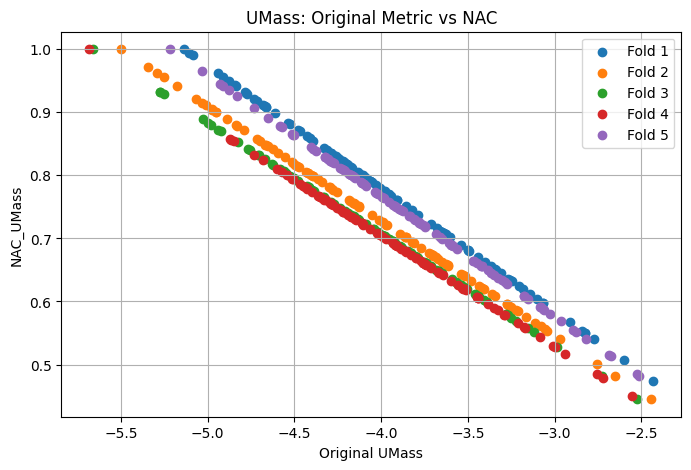

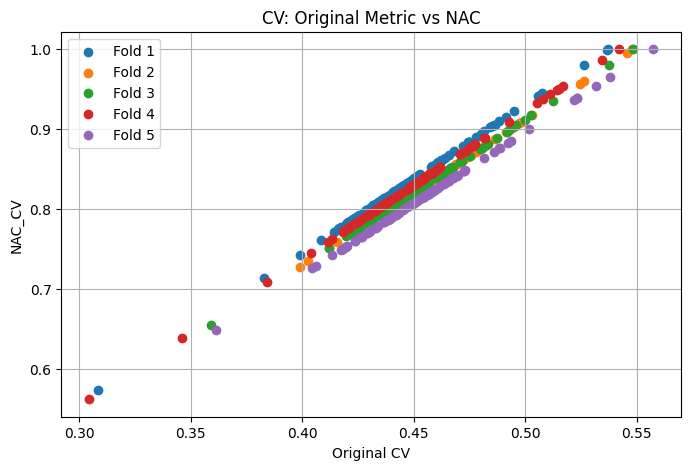

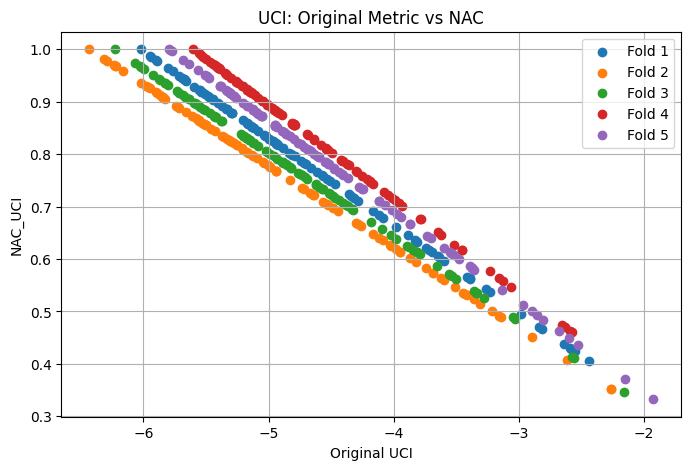

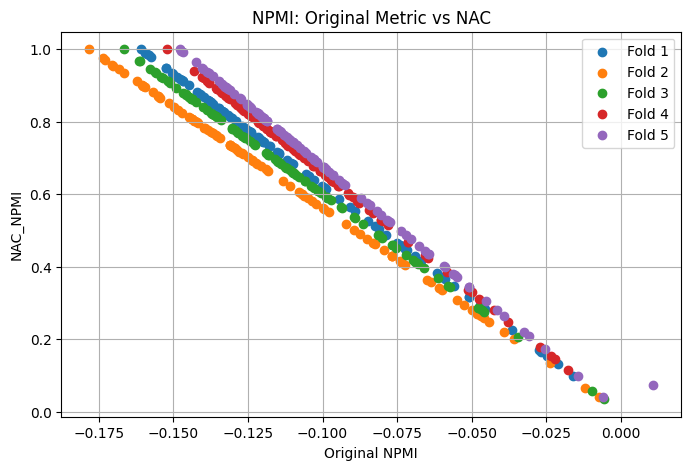

In [ ]:
# ============================================================
# 6K-9 Original Coherence vs NAC
# ============================================================

for (
    metric,
    original_column,
    abs_column,
    nac_column
) in metric_pairs:


    plt.figure(
        figsize=(8, 5)
    )


    for fold in sorted(
        nac_df["Fold"].dropna().unique()
    ):

        fold_df = nac_df[
            nac_df["Fold"] == fold
        ]


        plt.scatter(

            fold_df[
                original_column
            ],

            fold_df[
                nac_column
            ],

            label=f"Fold {fold}"
        )


    plt.xlabel(
        f"Original {metric}"
    )


    plt.ylabel(
        nac_column
    )


    plt.title(
        f"{metric}: Original Metric vs NAC"
    )


    plt.legend()


    plt.grid()


    plt.show()

In [ ]:
# ============================================================
# 6K-10 Save NAC Diagnostic Results
# ============================================================

sign_df.to_csv(
    ANALYSIS_DIR /
    "nac_sign_distribution.csv",
    index=False
)


diagnostic_df.to_csv(
    ANALYSIS_DIR /
    "nac_correlation_diagnostic.csv",
    index=False
)


best_k_comparison_df.to_csv(
    ANALYSIS_DIR /
    "nac_best_k_comparison.csv",
    index=False
)


ranking_df.to_csv(
    ANALYSIS_DIR /
    "nac_ranking_reversal.csv",
    index=False
)


direction_df.to_csv(
    ANALYSIS_DIR /
    "nac_direction_risk.csv",
    index=False
)


print(
    "✓ Fold-wise NAC diagnostic analysis completed."
)

✓ Fold-wise NAC diagnostic analysis completed.


In [ ]:
# ============================================================
# Notebook 6L — NAP Diagnostic Analysis
# ============================================================

# ============================================================
# 6L-1 Imports
# ============================================================

import numpy as np
import pandas as pd

from pathlib import Path

from scipy.stats import spearmanr

import matplotlib.pyplot as plt


# ============================================================
# 6L-2 Paths
# ============================================================

PROJECT_DIR = Path(
    "/content/drive/MyDrive/TopicEvalBench"
)

MODEL_DIR = PROJECT_DIR / "models"

ANALYSIS_DIR = (
    MODEL_DIR / "analysis"
)

ANALYSIS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 6L-3 Load Fold-wise NAP Results
# ============================================================

nap_file = (
    MODEL_DIR /
    "NAP.csv"
)

nap_df = pd.read_csv(
    nap_file
)

print("=" * 70)
print("NAP Diagnostic Analysis")
print("=" * 70)

print("\nNAP Shape:")
print(nap_df.shape)

print("\nNAP Columns:")
print(nap_df.columns.tolist())

display(
    nap_df.head()
)

NAP Diagnostic Analysis

NAP Shape:
(495, 7)

NAP Columns:
['ExperimentID', 'Fold', 'Topics', 'MeanLogPerplexity', 'PerplexityTest', 'AbsLogPerplexity', 'NAP']


,ExperimentID,Fold,Topics,MeanLogPerplexity,PerplexityTest,AbsLogPerplexity,NAP
0,F1_K002,1,2,-6.603739,97.257601,6.603739,0.480608
1,F1_K003,1,3,-6.728118,106.014498,6.728118,0.489660
2,F1_K004,1,4,-6.848727,115.258289,6.848727,0.498438
3,F1_K005,1,5,-6.998321,127.851162,6.998321,0.509325
4,F1_K006,1,6,-7.142265,141.265426,7.142265,0.519801


In [ ]:
# ============================================================
# 6L-4 Validate Required Columns
# ============================================================

required_columns = [

    "ExperimentID",

    "Fold",

    "Topics",

    "NAP"
]

missing_columns = [

    column
    for column in required_columns
    if column not in nap_df.columns
]

if missing_columns:

    raise ValueError(
        "Missing required columns in nap.csv:\n"
        f"{missing_columns}"
    )

print(
    "✓ Required NAP columns are available."
)

✓ Required NAP columns are available.


In [ ]:
# ============================================================
# 6L-5 Select Original Source Metric
# ============================================================

SOURCE_METRIC = (
    "MeanLogPerplexity"
)

if SOURCE_METRIC not in nap_df.columns:

    raise ValueError(
        f"{SOURCE_METRIC} "
        "is not available in NAP.csv."
    )

print(
    "✓ NAP source metric:",
    SOURCE_METRIC
)

✓ NAP source metric: MeanLogPerplexity


In [ ]:
# ============================================================
# 6L-6 Validate NAP Calculation
# ============================================================

nap_diagnostic_df = (
    nap_df.copy()
)

# Recalculate absolute value
nap_diagnostic_df[
    "RecalculatedAbsLogPerplexity"
] = (

    nap_diagnostic_df[
        SOURCE_METRIC
    ]
    .abs()
)

# Recalculate fold-wise NAP
nap_diagnostic_df[
    "RecalculatedNAP"
] = (

    nap_diagnostic_df[
        "RecalculatedAbsLogPerplexity"
    ]

    /

    nap_diagnostic_df.groupby(
        "Fold"
    )[
        "RecalculatedAbsLogPerplexity"
    ]
    .transform("max")
)

# Compare
nap_diagnostic_df[
    "NAPDifference"
] = (

    nap_diagnostic_df[
        "NAP"
    ]

    -

    nap_diagnostic_df[
        "RecalculatedNAP"
    ]

    .abs()
)

max_difference = (

    nap_diagnostic_df[
        "NAPDifference"
    ]
    .max()
)

print(
    "Maximum NAP difference:",
    max_difference
)

if max_difference < 1e-10:

    print(
        "✓ NAP calculation successfully verified."
    )

else:

    print(
        "WARNING: Saved NAP and recalculated "
        "NAP are different."
    )

Maximum NAP difference: 2.220446049250313e-16
✓ NAP calculation successfully verified.


In [ ]:
# ============================================================
# 6L-7 Log-Perplexity Sign Distribution
# ============================================================

negative_count = (

    nap_diagnostic_df[
        SOURCE_METRIC
    ] < 0

).sum()

positive_count = (

    nap_diagnostic_df[
        SOURCE_METRIC
    ] > 0

).sum()

zero_count = (

    nap_diagnostic_df[
        SOURCE_METRIC
    ] == 0

).sum()

total_count = len(
    nap_diagnostic_df
)

sign_distribution_df = pd.DataFrame({

    "Metric": [
        SOURCE_METRIC
    ],

    "Negative": [
        negative_count
    ],

    "Positive": [
        positive_count
    ],

    "Zero": [
        zero_count
    ],

    "Total": [
        total_count
    ],

    "NegativePercent": [
        100 * negative_count / total_count
    ],

    "PositivePercent": [
        100 * positive_count / total_count
    ]

})

display(
    sign_distribution_df
)

,Metric,Negative,Positive,Zero,Total,NegativePercent,PositivePercent
0,MeanLogPerplexity,495,0,0,495,100.0,0.0


In [ ]:
# ============================================================
# 6L-8 Fold-wise Ranking Equivalence and Reversal Diagnostic
# ============================================================

ranking_rows = []


for fold in sorted(
    nap_diagnostic_df["Fold"].unique()
):

    fold_df = (
        nap_diagnostic_df[
            nap_diagnostic_df["Fold"] == fold
        ]
        .copy()
    )


    # --------------------------------------------------------
    # Original criterion
    #
    # Higher LogPerplexityTest is better
    # because it corresponds to lower perplexity.
    # --------------------------------------------------------

    original_best_idx = (
        fold_df[
            "MeanLogPerplexity"
        ]
        .idxmax()
    )


    original_best_k = int(
        fold_df.loc[
            original_best_idx,
            "Topics"
        ]
    )


    original_value = (
        fold_df.loc[
            original_best_idx,
            "MeanLogPerplexity"
        ]
    )


    # --------------------------------------------------------
    # Absolute log-perplexity criterion
    #
    # Lower absolute value is better.
    # --------------------------------------------------------

    abs_best_idx = (
        fold_df[
            "AbsLogPerplexity"
        ]
        .idxmin()
    )


    abs_best_k = int(
        fold_df.loc[
            abs_best_idx,
            "Topics"
        ]
    )


    abs_value = (
        fold_df.loc[
            abs_best_idx,
            "AbsLogPerplexity"
        ]
    )


    # --------------------------------------------------------
    # NAP criterion
    #
    # Lower NAP is better.
    # --------------------------------------------------------

    nap_best_idx = (
        fold_df[
            "NAP"
        ]
        .idxmin()
    )


    nap_best_k = int(
        fold_df.loc[
            nap_best_idx,
            "Topics"
        ]
    )


    nap_value = (
        fold_df.loc[
            nap_best_idx,
            "NAP"
        ]
    )


    # --------------------------------------------------------
    # Ranking agreement
    # --------------------------------------------------------

    abs_agreement = (
        original_best_k
        ==
        abs_best_k
    )


    nap_agreement = (
        original_best_k
        ==
        nap_best_k
    )


    ranking_rows.append({

        "Fold": fold,

        "OriginalBestK":
            original_best_k,

        "OriginalLogPerplexity":
            original_value,

        "AbsBestK":
            abs_best_k,

        "AbsLogPerplexity":
            abs_value,

        "NAPBestK":
            nap_best_k,

        "NAPValue":
            nap_value,

        "OriginalVsAbsAgreement":
            abs_agreement,

        "OriginalVsNAPAgreement":
            nap_agreement,

        "AbsRankingReversal":
            not abs_agreement,

        "NAPRankingReversal":
            not nap_agreement

    })


# ============================================================
# Create Result DataFrame
# ============================================================

nap_ranking_df = pd.DataFrame(
    ranking_rows
)


display(
    nap_ranking_df
)

,Fold,OriginalBestK,OriginalLogPerplexity,AbsBestK,AbsLogPerplexity,NAPBestK,NAPValue,OriginalVsAbsAgreement,OriginalVsNAPAgreement,AbsRankingReversal,NAPRankingReversal
0,1,2,-6.603739,2,6.603739,2,0.480608,True,True,False,False
1,2,2,-6.615859,2,6.615859,2,0.484170,True,True,False,False
2,3,2,-6.555923,2,6.555923,2,0.491556,True,True,False,False
3,4,2,-6.655874,2,6.655874,2,0.471792,True,True,False,False
4,5,2,-6.633514,2,6.633514,2,0.469086,True,True,False,False


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=nap_ranking_df)

https://docs.google.com/spreadsheets/d/198bvm8b7nwEThwJeJkvvbwm_7po3V63q0yx1NvILCzI/edit#gid=0


In [ ]:
# ============================================================
# 6L-9 NAP Ranking Agreement Summary
# ============================================================

nap_summary_df = pd.DataFrame({

    "Diagnostic": [

        "Total Folds",

        "Original vs Absolute Agreement",

        "Original vs NAP Agreement",

        "Absolute Ranking Reversals",

        "NAP Ranking Reversals"

    ],

    "Count": [

        len(nap_ranking_df),

        nap_ranking_df[
            "OriginalVsAbsAgreement"
        ].sum(),

        nap_ranking_df[
            "OriginalVsNAPAgreement"
        ].sum(),

        nap_ranking_df[
            "AbsRankingReversal"
        ].sum(),

        nap_ranking_df[
            "NAPRankingReversal"
        ].sum()

    ]

})


nap_summary_df[
    "Percentage"
] = (

    nap_summary_df[
        "Count"
    ]

    /

    len(nap_ranking_df)

    *

    100

)


display(
    nap_summary_df
)

,Diagnostic,Count,Percentage
0,Total Folds,5,100.0
1,Original vs Absolute Agreement,5,100.0
2,Original vs NAP Agreement,5,100.0
3,Absolute Ranking Reversals,0,0.0
4,NAP Ranking Reversals,0,0.0


In [ ]:
# ============================================================
# 6L-10 NAP Downstream Efficacy Diagnostic
# ============================================================

# ------------------------------------------------------------
# Load central analysis dataset
# ------------------------------------------------------------

central_analysis_file = (
    ANALYSIS_DIR /
    "central_analysis.csv"
)

central_analysis_df = pd.read_csv(
    central_analysis_file
)

print("=" * 70)
print("NAP Downstream Efficacy Diagnostic")
print("=" * 70)

print(
    "Central analysis shape:",
    central_analysis_df.shape
)


# ------------------------------------------------------------
# Validate required columns
# ------------------------------------------------------------

required_columns = [

    "Fold",

    "Topics",

    "Mean_MCC"
]


missing_columns = [

    column
    for column in required_columns
    if column not in central_analysis_df.columns
]


if missing_columns:

    raise ValueError(
        "Missing columns in central_analysis.csv:\n"
        f"{missing_columns}"
    )


print(
    "✓ Required downstream columns are available."
)


# ------------------------------------------------------------
# Ensure one downstream observation per Fold-Topics
# ------------------------------------------------------------

downstream_df = (

    central_analysis_df[
        [

            "Fold",

            "Topics",

            "Mean_MCC"

        ]
    ]

    .drop_duplicates(

        subset=[

            "Fold",

            "Topics"

        ]
    )

    .copy()
)


# ------------------------------------------------------------
# Merge downstream performance with NAP
# ------------------------------------------------------------

nap_downstream_df = (

    nap_diagnostic_df[
        [

            "Fold",

            "Topics",

            "MeanLogPerplexity",

            "AbsLogPerplexity",

            "NAP"

        ]
    ]

    .merge(

        downstream_df,

        on=[

            "Fold",

            "Topics"

        ],

        how="left",

        validate="one_to_one"

    )
)


# ------------------------------------------------------------
# Validate downstream merge
# ------------------------------------------------------------

missing_mcc = (

    nap_downstream_df[
        "Mean_MCC"
    ]
    .isna()
    .sum()
)


if missing_mcc > 0:

    raise ValueError(
        f"{missing_mcc} experiments "
        "could not be matched with Mean_MCC."
    )


print(
    "✓ NAP successfully merged "
    "with downstream Mean_MCC."
)


# ============================================================
# Compare NAP-selected K with downstream-optimal K
# ============================================================

efficacy_rows = []


for fold in sorted(
    nap_downstream_df[
        "Fold"
    ]
    .unique()
):

    fold_df = (

        nap_downstream_df[
            nap_downstream_df[
                "Fold"
            ] == fold
        ]

        .copy()
    )


    # --------------------------------------------------------
    # NAP-selected K
    #
    # Lower NAP is better
    # --------------------------------------------------------

    nap_best_idx = (

        fold_df[
            "NAP"
        ]
        .idxmin()
    )


    nap_best_k = int(

        fold_df.loc[
            nap_best_idx,
            "Topics"
        ]
    )


    nap_best_value = (

        fold_df.loc[
            nap_best_idx,
            "NAP"
        ]
    )


    nap_selected_mcc = (

        fold_df.loc[
            nap_best_idx,
            "Mean_MCC"
        ]
    )


    # --------------------------------------------------------
    # Downstream-optimal K
    #
    # Higher MCC is better
    # --------------------------------------------------------

    downstream_best_idx = (

        fold_df[
            "Mean_MCC"
        ]
        .idxmax()
    )


    downstream_best_k = int(

        fold_df.loc[
            downstream_best_idx,
            "Topics"
        ]
    )


    downstream_best_mcc = (

        fold_df.loc[
            downstream_best_idx,
            "Mean_MCC"
        ]
    )


    # --------------------------------------------------------
    # Performance loss
    # --------------------------------------------------------

    mcc_loss = (

        downstream_best_mcc
        -
        nap_selected_mcc
    )


    # --------------------------------------------------------
    # Selection agreement
    # --------------------------------------------------------

    k_agreement = (

        nap_best_k
        ==
        downstream_best_k
    )


    efficacy_rows.append({

        "Fold": fold,

        "NAP_SelectedK":
            nap_best_k,

        "NAP_Value":
            nap_best_value,

        "NAP_Selected_MCC":
            nap_selected_mcc,

        "DownstreamOptimalK":
            downstream_best_k,

        "DownstreamOptimalMCC":
            downstream_best_mcc,

        "K_Agreement":
            k_agreement,

        "MCC_Loss":
            mcc_loss

    })


# ============================================================
# Create efficacy DataFrame
# ============================================================

nap_efficacy_df = pd.DataFrame(
    efficacy_rows
)


display(
    nap_efficacy_df
)


# ============================================================
# Summary
# ============================================================

nap_efficacy_summary = pd.DataFrame({

    "Metric": [

        "Total Folds",

        "K Agreement Count",

        "K Agreement Percentage",

        "Mean MCC Loss",

        "Median MCC Loss",

        "Maximum MCC Loss"

    ],

    "Value": [

        len(nap_efficacy_df),

        nap_efficacy_df[
            "K_Agreement"
        ]
        .sum(),

        (
            nap_efficacy_df[
                "K_Agreement"
            ]
            .mean()
            * 100
        ),

        nap_efficacy_df[
            "MCC_Loss"
        ]
        .mean(),

        nap_efficacy_df[
            "MCC_Loss"
        ]
        .median(),

        nap_efficacy_df[
            "MCC_Loss"
        ]
        .max()

    ]

})


print("\nNAP Downstream Efficacy Summary")

display(
    nap_efficacy_summary
)

NAP Downstream Efficacy Diagnostic
Central analysis shape: (495, 63)
✓ Required downstream columns are available.
✓ NAP successfully merged with downstream Mean_MCC.


,Fold,NAP_SelectedK,NAP_Value,NAP_Selected_MCC,DownstreamOptimalK,DownstreamOptimalMCC,K_Agreement,MCC_Loss
0,1,2,0.480608,0.232401,22,0.939813,False,0.707411
1,2,2,0.484170,0.258608,30,0.933248,False,0.674640
2,3,2,0.491556,0.176914,29,0.933819,False,0.756905
3,4,2,0.471792,0.176705,24,0.836431,False,0.659726
4,5,2,0.469086,0.284528,16,0.890816,False,0.606287



NAP Downstream Efficacy Summary


,Metric,Value
0,Total Folds,5.000000
1,K Agreement Count,0.000000
2,K Agreement Percentage,0.000000
3,Mean MCC Loss,0.680994
4,Median MCC Loss,0.674640
5,Maximum MCC Loss,0.756905


In [ ]:
# ============================================================
# 6L-11 Save NAP Diagnostic Results
# ============================================================

# ------------------------------------------------------------
# Output files
# ------------------------------------------------------------

nap_ranking_file = (
    ANALYSIS_DIR /
    "nap_ranking_equivalence.csv"
)


nap_summary_file = (
    ANALYSIS_DIR /
    "nap_ranking_summary.csv"
)


nap_efficacy_file = (
    ANALYSIS_DIR /
    "nap_downstream_efficacy.csv"
)


nap_efficacy_summary_file = (
    ANALYSIS_DIR /
    "nap_downstream_efficacy_summary.csv"
)


# ------------------------------------------------------------
# Save ranking diagnostic
# ------------------------------------------------------------

nap_ranking_df.to_csv(
    nap_ranking_file,
    index=False
)


# ------------------------------------------------------------
# Save ranking summary
# ------------------------------------------------------------

nap_summary_df.to_csv(
    nap_summary_file,
    index=False
)


# ------------------------------------------------------------
# Save downstream efficacy results
# ------------------------------------------------------------

nap_efficacy_df.to_csv(
    nap_efficacy_file,
    index=False
)


# ------------------------------------------------------------
# Save downstream efficacy summary
# ------------------------------------------------------------

nap_efficacy_summary.to_csv(
    nap_efficacy_summary_file,
    index=False
)


# ------------------------------------------------------------
# Confirmation
# ------------------------------------------------------------

print("=" * 70)

print(
    "NAP Diagnostic Files Saved Successfully"
)

print("=" * 70)


print("\n1. Ranking Equivalence:")
print(nap_ranking_file)


print("\n2. Ranking Summary:")
print(nap_summary_file)


print("\n3. Downstream Efficacy:")
print(nap_efficacy_file)


print("\n4. Downstream Efficacy Summary:")
print(nap_efficacy_summary_file)

NAP Diagnostic Files Saved Successfully

1. Ranking Equivalence:
/content/drive/MyDrive/TopicEvalBench/models/analysis/nap_ranking_equivalence.csv

2. Ranking Summary:
/content/drive/MyDrive/TopicEvalBench/models/analysis/nap_ranking_summary.csv

3. Downstream Efficacy:
/content/drive/MyDrive/TopicEvalBench/models/analysis/nap_downstream_efficacy.csv

4. Downstream Efficacy Summary:
/content/drive/MyDrive/TopicEvalBench/models/analysis/nap_downstream_efficacy_summary.csv


In [ ]:

# ============================================================
# 6L-12 Overall NAP Diagnostic Conclusion
# ============================================================

print("=" * 70)
print("OVERALL NAP DIAGNOSTIC CONCLUSION")
print("=" * 70)


# ------------------------------------------------------------
# Ranking diagnostic
# ------------------------------------------------------------

total_folds = len(
    nap_ranking_df
)

original_abs_agreement = (
    nap_ranking_df[
        "OriginalVsAbsAgreement"
    ]
    .sum()
)

original_nap_agreement = (
    nap_ranking_df[
        "OriginalVsNAPAgreement"
    ]
    .sum()
)

abs_reversals = (
    nap_ranking_df[
        "AbsRankingReversal"
    ]
    .sum()
)

nap_reversals = (
    nap_ranking_df[
        "NAPRankingReversal"
    ]
    .sum()
)


# ------------------------------------------------------------
# Downstream efficacy diagnostic
# ------------------------------------------------------------

k_agreement_count = (
    nap_efficacy_df[
        "K_Agreement"
    ]
    .sum()
)

k_agreement_percentage = (
    nap_efficacy_df[
        "K_Agreement"
    ]
    .mean()
    * 100
)

mean_mcc_loss = (
    nap_efficacy_df[
        "MCC_Loss"
    ]
    .mean()
)

median_mcc_loss = (
    nap_efficacy_df[
        "MCC_Loss"
    ]
    .median()
)

max_mcc_loss = (
    nap_efficacy_df[
        "MCC_Loss"
    ]
    .max()
)


# ------------------------------------------------------------
# Topic-selection statistics
# ------------------------------------------------------------

nap_selected_k_values = (
    nap_efficacy_df[
        "NAP_SelectedK"
    ]
    .tolist()
)

downstream_selected_k_values = (
    nap_efficacy_df[
        "DownstreamOptimalK"
    ]
    .tolist()
)


# ------------------------------------------------------------
# Create final diagnostic table
# ------------------------------------------------------------

nap_conclusion_df = pd.DataFrame({

    "Diagnostic": [

        "Total folds",

        "Original vs Absolute ranking agreement",

        "Original vs NAP ranking agreement",

        "Absolute ranking reversals",

        "NAP ranking reversals",

        "NAP downstream K agreement",

        "NAP downstream K agreement percentage",

        "Mean MCC loss",

        "Median MCC loss",

        "Maximum MCC loss",

        "NAP-selected K values",

        "Downstream-optimal K values"

    ],

    "Result": [

        total_folds,

        f"{original_abs_agreement}/{total_folds}",

        f"{original_nap_agreement}/{total_folds}",

        abs_reversals,

        nap_reversals,

        f"{k_agreement_count}/{total_folds}",

        k_agreement_percentage,

        mean_mcc_loss,

        median_mcc_loss,

        max_mcc_loss,

        str(nap_selected_k_values),

        str(downstream_selected_k_values)

    ]

})


display(
    nap_conclusion_df
)


# ============================================================
# Print Research Interpretation
# ============================================================

print("\n")
print("=" * 70)
print("INTERPRETATION")
print("=" * 70)

print(
    "\n1. Ranking validity:"
)

if nap_reversals == 0:

    print(
        "NAP preserved the original "
        "log-perplexity topic ranking "
        f"in all {total_folds} folds."
    )

else:

    print(
        f"NAP produced ranking reversals "
        f"in {nap_reversals} folds."
    )


print(
    "\n2. Downstream topic-selection efficacy:"
)

print(
    f"NAP matched the downstream-optimal "
    f"K in {k_agreement_count}/{total_folds} folds "
    f"({k_agreement_percentage:.2f}%)."
)


print(
    "\n3. Downstream performance loss:"
)

print(
    f"Mean MCC loss   : {mean_mcc_loss:.6f}"
)

print(
    f"Median MCC loss : {median_mcc_loss:.6f}"
)

print(
    f"Maximum MCC loss: {max_mcc_loss:.6f}"
)


print(
    "\n4. Overall conclusion:"
)

if nap_reversals == 0 and k_agreement_count == 0:

    print(
        "NAP is mathematically ranking-consistent "
        "with the original log-perplexity criterion "
        "in this experiment, but it does not align "
        "with downstream-optimal topic selection."
    )

elif nap_reversals == 0:

    print(
        "NAP preserves the original perplexity ranking "
        "and shows partial downstream alignment."
    )

else:

    print(
        "NAP shows both ranking-related and "
        "downstream topic-selection limitations."
    )

OVERALL NAP DIAGNOSTIC CONCLUSION


,Diagnostic,Result
0,Total folds,5
1,Original vs Absolute ranking agreement,5/5
2,Original vs NAP ranking agreement,5/5
3,Absolute ranking reversals,0
4,NAP ranking reversals,0
5,NAP downstream K agreement,0/5
6,NAP downstream K agreement percentage,0.0
7,Mean MCC loss,0.680994
8,Median MCC loss,0.67464
9,Maximum MCC loss,0.756905




INTERPRETATION

1. Ranking validity:
NAP preserved the original log-perplexity topic ranking in all 5 folds.

2. Downstream topic-selection efficacy:
NAP matched the downstream-optimal K in 0/5 folds (0.00%).

3. Downstream performance loss:
Mean MCC loss   : 0.680994
Median MCC loss : 0.674640
Maximum MCC loss: 0.756905

4. Overall conclusion:
NAP is mathematically ranking-consistent with the original log-perplexity criterion in this experiment, but it does not align with downstream-optimal topic selection.


In [ ]:

# ============================================================
# 6M-1 Load NAC and NAP Diagnostic Results
# ============================================================

print("=" * 70)
print("COMBINED NAC VS NAP DIAGNOSTIC ANALYSIS")
print("=" * 70)


# ------------------------------------------------------------
# NAC diagnostic files
# ------------------------------------------------------------

nac_best_k_file = (
    ANALYSIS_DIR /
    "nac_best_k_comparison.csv"
)

nac_direction_risk_file = (
    ANALYSIS_DIR /
    "nac_direction_risk.csv"
)

nac_sign_distribution_file = (
    ANALYSIS_DIR /
    "nac_sign_distribution.csv"
)

nac_correlation_file = (
    ANALYSIS_DIR /
    "nac_correlation_diagnostic.csv"
)

nac_ranking_file = (
    ANALYSIS_DIR /
    "nac_ranking_reversal.csv"
)


# ------------------------------------------------------------
# NAP diagnostic files
# ------------------------------------------------------------

nap_ranking_file = (
    ANALYSIS_DIR /
    "nap_ranking_equivalence.csv"
)

nap_summary_file = (
    ANALYSIS_DIR /
    "nap_ranking_summary.csv"
)

nap_efficacy_file = (
    ANALYSIS_DIR /
    "nap_downstream_efficacy.csv"
)

nap_efficacy_summary_file = (
    ANALYSIS_DIR /
    "nap_downstream_efficacy_summary.csv"
)


# ------------------------------------------------------------
# Load files
# ------------------------------------------------------------

nac_best_k_df = pd.read_csv(
    nac_best_k_file
)

nac_direction_risk_df = pd.read_csv(
    nac_direction_risk_file
)

nac_sign_distribution_df = pd.read_csv(
    nac_sign_distribution_file
)

nac_correlation_df = pd.read_csv(
    nac_correlation_file
)

nac_ranking_df = pd.read_csv(
    nac_ranking_file
)


nap_ranking_df = pd.read_csv(
    nap_ranking_file
)

nap_summary_df = pd.read_csv(
    nap_summary_file
)

nap_efficacy_df = pd.read_csv(
    nap_efficacy_file
)

nap_efficacy_summary_df = pd.read_csv(
    nap_efficacy_summary_file
)


print("\n✓ NAC diagnostic files loaded.")
print("✓ NAP diagnostic files loaded.")


print("\nNAC best-K shape:",
      nac_best_k_df.shape)

print("NAP efficacy shape:",
      nap_efficacy_df.shape)

COMBINED NAC VS NAP DIAGNOSTIC ANALYSIS

✓ NAC diagnostic files loaded.
✓ NAP diagnostic files loaded.

NAC best-K shape: (20, 6)
NAP efficacy shape: (5, 8)


In [ ]:

# ============================================================
# 6M-2 Inspect Diagnostic File Structures
# ============================================================

diagnostic_files = {

    "NAC Best-K":
        nac_best_k_df,

    "NAC Direction Risk":
        nac_direction_risk_df,

    "NAC Sign Distribution":
        nac_sign_distribution_df,

    "NAC Correlation":
        nac_correlation_df,

    "NAC Ranking Reversal":
        nac_ranking_df,

    "NAP Ranking":
        nap_ranking_df,

    "NAP Efficacy":
        nap_efficacy_df

}


for name, df in diagnostic_files.items():

    print("\n" + "=" * 70)

    print(name)

    print("=" * 70)

    print(
        df.columns.tolist()
    )

    display(
        df.head()
    )


NAC Best-K
['Fold', 'Metric', 'OriginalSelectedK', 'NACSelectedK', 'KDifference', 'SameSelectedK']


,Fold,Metric,OriginalSelectedK,NACSelectedK,KDifference,SameSelectedK
0,1,UMass,13,97,84,False
1,1,CV,11,11,0,True
2,1,UCI,9,97,88,False
3,1,NPMI,9,97,88,False
4,2,UMass,7,98,91,False



NAC Direction Risk
['Metric', 'NegativeCount', 'TotalCount', 'NegativeRatio', 'ContainsNegativeValues', 'AbsoluteNormalizationRisk']


,Metric,NegativeCount,TotalCount,NegativeRatio,ContainsNegativeValues,AbsoluteNormalizationRisk
0,UMass,495,495,1.00000,True,HIGH
1,CV,0,495,0.00000,False,LOW
2,UCI,495,495,1.00000,True,HIGH
3,NPMI,494,495,0.99798,True,HIGH



NAC Sign Distribution
['Metric', 'Positive', 'Negative', 'Zero', 'Minimum', 'Maximum', 'Mean', 'Total']


...

,Fold,Metric,MeanRankDifference,MaximumRankDifference,DifferentRanks,TotalTopics
0,1,UMass,49.494949,98.0,98,99
1,1,CV,0.000000,0.0,0,99
2,1,UCI,49.494949,98.0,98,99
3,1,NPMI,49.494949,98.0,98,99
4,2,UMass,49.494949,98.0,98,99



NAP Ranking
['Fold', 'OriginalBestK', 'OriginalLogPerplexity', 'AbsBestK', 'AbsLogPerplexity', 'NAPBestK', 'NAPValue', 'OriginalVsAbsAgreement', 'OriginalVsNAPAgreement', 'AbsRankingReversal', 'NAPRankingReversal']


,Fold,OriginalBestK,OriginalLogPerplexity,AbsBestK,AbsLogPerplexity,NAPBestK,NAPValue,OriginalVsAbsAgreement,OriginalVsNAPAgreement,AbsRankingReversal,NAPRankingReversal
0,1,2,-6.603739,2,6.603739,2,0.480608,True,True,False,False
1,2,2,-6.615859,2,6.615859,2,0.484170,True,True,False,False
2,3,2,-6.555923,2,6.555923,2,0.491556,True,True,False,False
3,4,2,-6.655874,2,6.655874,2,0.471792,True,True,False,False
4,5,2,-6.633514,2,6.633514,2,0.469086,True,True,False,False



NAP Efficacy
['Fold', 'NAP_SelectedK', 'NAP_Value', 'NAP_Selected_MCC', 'DownstreamOptimalK', 'DownstreamOptimalMCC', 'K_Agreement', 'MCC_Loss']


,Fold,NAP_SelectedK,NAP_Value,NAP_Selected_MCC,DownstreamOptimalK,DownstreamOptimalMCC,K_Agreement,MCC_Loss
0,1,2,0.480608,0.232401,22,0.939813,False,0.707411
1,2,2,0.484170,0.258608,30,0.933248,False,0.674640
2,3,2,0.491556,0.176914,29,0.933819,False,0.756905
3,4,2,0.471792,0.176705,24,0.836431,False,0.659726
4,5,2,0.469086,0.284528,16,0.890816,False,0.606287


In [ ]:

# ============================================================
# 6M-3 Create Combined NAC vs NAP Diagnostic Summary
# ============================================================

combined_rows = []


# ============================================================
# NAC Diagnostics
# ============================================================

for metric in nac_direction_risk_df["Metric"].unique():

    # --------------------------------------------------------
    # Direction risk
    # --------------------------------------------------------

    risk_row = nac_direction_risk_df[
        nac_direction_risk_df["Metric"] == metric
    ].iloc[0]


    # --------------------------------------------------------
    # Best-K comparison
    # --------------------------------------------------------

    best_k_metric = nac_best_k_df[
        nac_best_k_df["Metric"] == metric
    ].copy()


    total_folds = len(best_k_metric)

    same_k_count = (
        best_k_metric[
            "SameSelectedK"
        ]
        .sum()
    )


    same_k_percentage = (
        best_k_metric[
            "SameSelectedK"
        ]
        .mean()
        * 100
    )


    # --------------------------------------------------------
    # Ranking reversal statistics
    # --------------------------------------------------------

    ranking_metric = nac_ranking_df[
        nac_ranking_df["Metric"] == metric
    ].copy()


    mean_rank_difference = (
        ranking_metric[
            "MeanRankDifference"
        ]
        .mean()
    )


    max_rank_difference = (
        ranking_metric[
            "MaximumRankDifference"
        ]
        .max()
    )


    different_rank_count = (
        ranking_metric[
            "DifferentRanks"
        ]
        .sum()
    )


    total_ranked_topics = (
        ranking_metric[
            "TotalTopics"
        ]
        .sum()
    )


    # --------------------------------------------------------
    # Correlation diagnostic
    # --------------------------------------------------------

    correlation_row = nac_correlation_df[
        nac_correlation_df["Metric"] == metric
    ].iloc[0]


    # --------------------------------------------------------
    # Add result
    # --------------------------------------------------------

    combined_rows.append({

        "Metric":
            f"NAC_{metric}",

        "MetricFamily":
            "NAC",

        "BaseMetric":
            metric,

        "DirectionRisk":
            risk_row[
                "AbsoluteNormalizationRisk"
            ],

        "NegativeRatio":
            risk_row[
                "NegativeRatio"
            ],

        "OriginalVsAbsoluteSpearman":
            correlation_row[
                "Spearman_Original_vs_Absolute"
            ],

        "OriginalVsNACSpearman":
            correlation_row[
                "Spearman_Original_vs_NAC"
            ],

        "OriginalSelectionAgreement":
            f"{same_k_count}/{total_folds}",

        "OriginalSelectionAgreementPercent":
            same_k_percentage,

        "MeanRankDifference":
            mean_rank_difference,

        "MaximumRankDifference":
            max_rank_difference,

        "DifferentRanks":
            different_rank_count,

        "TotalRankedTopics":
            total_ranked_topics,

        "FailureMechanism":
            (
                "Direction distortion risk "
                "from absolute-value normalization"
            )

    })


# ============================================================
# NAP Diagnostics
# ============================================================

nap_total_folds = len(
    nap_ranking_df
)


nap_original_agreement_count = (
    nap_ranking_df[
        "OriginalVsNAPAgreement"
    ]
    .sum()
)


nap_original_agreement_percentage = (

    nap_ranking_df[
        "OriginalVsNAPAgreement"
    ]
    .mean()
    * 100
)


nap_ranking_reversals = (

    nap_ranking_df[
        "NAPRankingReversal"
    ]
    .sum()
)


nap_k_agreement_count = (

    nap_efficacy_df[
        "K_Agreement"
    ]
    .sum()
)


nap_k_agreement_percentage = (

    nap_efficacy_df[
        "K_Agreement"
    ]
    .mean()
    * 100
)


nap_mean_mcc_loss = (

    nap_efficacy_df[
        "MCC_Loss"
    ]
    .mean()
)


nap_median_mcc_loss = (

    nap_efficacy_df[
        "MCC_Loss"
    ]
    .median()
)


nap_max_mcc_loss = (

    nap_efficacy_df[
        "MCC_Loss"
    ]
    .max()
)


combined_rows.append({

    "Metric":
        "NAP",

    "MetricFamily":
        "NAP",

    "BaseMetric":
        "LogPerplexity",

    "DirectionRisk":
        "LOW",

    "NegativeRatio":
        np.nan,

    "OriginalVsAbsoluteSpearman":
        np.nan,

    "OriginalVsNACSpearman":
        np.nan,

    "OriginalSelectionAgreement":
        (
            f"{nap_original_agreement_count}"
            f"/{nap_total_folds}"
        ),

    "OriginalSelectionAgreementPercent":
        nap_original_agreement_percentage,

    "MeanRankDifference":
        0.0,

    "MaximumRankDifference":
        0.0,

    "DifferentRanks":
        nap_ranking_reversals,

    "TotalRankedTopics":
        np.nan,

    "FailureMechanism":
        (
            "Downstream criterion misalignment"
        )

})


# ============================================================
# Create Combined DataFrame
# ============================================================

combined_diagnostic_df = pd.DataFrame(
    combined_rows
)


display(
    combined_diagnostic_df
)

,Metric,MetricFamily,BaseMetric,DirectionRisk,NegativeRatio,OriginalVsAbsoluteSpearman,OriginalVsNACSpearman,OriginalSelectionAgreement,OriginalSelectionAgreementPercent,MeanRankDifference,MaximumRankDifference,DifferentRanks,TotalRankedTopics,FailureMechanism
0,NAC_UMass,NAC,UMass,HIGH,1.00000,-1.000000,-0.959286,0/5,0.0,49.494949,98.0,490,495.0,Direction distortion risk from absolute-value ...
1,NAC_CV,NAC,CV,LOW,0.00000,1.000000,0.963309,5/5,100.0,0.000000,0.0,0,495.0,Direction distortion risk from absolute-value ...
2,NAC_UCI,NAC,UCI,HIGH,1.00000,-1.000000,-0.943636,0/5,0.0,49.494949,98.0,490,495.0,Direction distortion risk from absolute-value ...
3,NAC_NPMI,NAC,NPMI,HIGH,0.99798,-0.999999,-0.961054,0/5,0.0,49.494949,98.0,490,495.0,Direction distortion risk from absolute-value ...
4,NAP,NAP,LogPerplexity,LOW,NaN,NaN,NaN,5/5,100.0,0.000000,0.0,0,NaN,Downstream criterion misalignment


In [ ]:

# ============================================================
# 6M-4 NAP Downstream Efficacy Summary
# ============================================================

nap_downstream_summary_df = pd.DataFrame({

    "Metric": [

        "NAP"

    ],

    "DownstreamKAgreement": [

        f"{nap_k_agreement_count}/{nap_total_folds}"

    ],

    "DownstreamKAgreementPercent": [

        nap_k_agreement_percentage

    ],

    "MeanMCCLoss": [

        nap_mean_mcc_loss

    ],

    "MedianMCCLoss": [

        nap_median_mcc_loss

    ],

    "MaximumMCCLoss": [

        nap_max_mcc_loss

    ]

})


display(
    nap_downstream_summary_df
)

,Metric,DownstreamKAgreement,DownstreamKAgreementPercent,MeanMCCLoss,MedianMCCLoss,MaximumMCCLoss
0,NAP,0/5,0.0,0.680994,0.67464,0.756905


In [ ]:

# ============================================================
# 6M-5 Final NAC vs NAP Diagnostic Comparison
# ============================================================

final_rows = []


# ============================================================
# NAC Metrics
# ============================================================

for metric in nac_direction_risk_df["Metric"].unique():

    # --------------------------------------------------------
    # Direction risk
    # --------------------------------------------------------

    risk = nac_direction_risk_df[
        nac_direction_risk_df["Metric"] == metric
    ].iloc[0]


    # --------------------------------------------------------
    # Best-K comparison
    # --------------------------------------------------------

    best_k = nac_best_k_df[
        nac_best_k_df["Metric"] == metric
    ]


    total_folds = len(best_k)

    agreement_count = (
        best_k["SameSelectedK"]
        .sum()
    )


    agreement_percent = (
        best_k["SameSelectedK"]
        .mean()
        * 100
    )


    # --------------------------------------------------------
    # Ranking comparison
    # --------------------------------------------------------

    ranking = nac_ranking_df[
        nac_ranking_df["Metric"] == metric
    ]


    mean_rank_difference = (
        ranking["MeanRankDifference"]
        .mean()
    )


    max_rank_difference = (
        ranking["MaximumRankDifference"]
        .max()
    )


    different_ranks = (
        ranking["DifferentRanks"]
        .sum()
    )


    total_topics = (
        ranking["TotalTopics"]
        .sum()
    )


    # --------------------------------------------------------
    # Original vs NAC correlation
    # --------------------------------------------------------

    corr = nac_correlation_df[
        nac_correlation_df["Metric"] == metric
    ].iloc[0]


    # --------------------------------------------------------
    # Determine diagnostic outcome
    # --------------------------------------------------------

    if risk[
        "AbsoluteNormalizationRisk"
    ] == "HIGH":

        diagnostic_outcome = (
            "Direction-sensitive ranking distortion risk"
        )

    else:

        diagnostic_outcome = (
            "No major direction distortion detected"
        )


    # --------------------------------------------------------
    # Add NAC row
    # --------------------------------------------------------

    final_rows.append({

        "Metric":
            f"NAC_{metric}",

        "MetricType":
            "Normalized Coherence",

        "BaseCriterion":
            metric,

        "DirectionRisk":
            risk[
                "AbsoluteNormalizationRisk"
            ],

        "NegativeRatio":
            risk[
                "NegativeRatio"
            ],

        "OriginalVsNACSpearman":
            corr[
                "Spearman_Original_vs_NAC"
            ],

        "OriginalKAgreement":
            f"{agreement_count}/{total_folds}",

        "OriginalKAgreementPercent":
            agreement_percent,

        "MeanRankDifference":
            mean_rank_difference,

        "MaximumRankDifference":
            max_rank_difference,

        "DifferentRanks":
            different_ranks,

        "TotalRankedTopics":
            total_topics,

        "DownstreamKAgreement":
            np.nan,

        "DownstreamKAgreementPercent":
            np.nan,

        "MeanMCCLoss":
            np.nan,

        "FailureMechanism":
            diagnostic_outcome

    })


# ============================================================
# NAP Row
# ============================================================

final_rows.append({

    "Metric":
        "NAP",

    "MetricType":
        "Normalized Perplexity",

    "BaseCriterion":
        "LogPerplexity",

    "DirectionRisk":
        "LOW",

    "NegativeRatio":
        np.nan,

    "OriginalVsNACSpearman":
        np.nan,

    "OriginalKAgreement":
        f"{nap_original_agreement_count}/{nap_total_folds}",

    "OriginalKAgreementPercent":
        nap_original_agreement_percentage,

    "MeanRankDifference":
        0.0,

    "MaximumRankDifference":
        0.0,

    "DifferentRanks":
        nap_ranking_reversals,

    "TotalRankedTopics":
        np.nan,

    "DownstreamKAgreement":
        f"{nap_k_agreement_count}/{nap_total_folds}",

    "DownstreamKAgreementPercent":
        nap_k_agreement_percentage,

    "MeanMCCLoss":
        nap_mean_mcc_loss,

    "FailureMechanism":
        (
            "Downstream criterion misalignment"
        )

})


# ============================================================
# Create Final Table
# ============================================================

final_diagnostic_df = pd.DataFrame(
    final_rows
)


display(
    final_diagnostic_df
)

,Metric,MetricType,BaseCriterion,DirectionRisk,NegativeRatio,OriginalVsNACSpearman,OriginalKAgreement,OriginalKAgreementPercent,MeanRankDifference,MaximumRankDifference,DifferentRanks,TotalRankedTopics,DownstreamKAgreement,DownstreamKAgreementPercent,MeanMCCLoss,FailureMechanism
0,NAC_UMass,Normalized Coherence,UMass,HIGH,1.00000,-0.959286,0/5,0.0,49.494949,98.0,490,495.0,NaN,NaN,NaN,Direction-sensitive ranking distortion risk
1,NAC_CV,Normalized Coherence,CV,LOW,0.00000,0.963309,5/5,100.0,0.000000,0.0,0,495.0,NaN,NaN,NaN,No major direction distortion detected
2,NAC_UCI,Normalized Coherence,UCI,HIGH,1.00000,-0.943636,0/5,0.0,49.494949,98.0,490,495.0,NaN,NaN,NaN,Direction-sensitive ranking distortion risk
3,NAC_NPMI,Normalized Coherence,NPMI,HIGH,0.99798,-0.961054,0/5,0.0,49.494949,98.0,490,495.0,NaN,NaN,NaN,Direction-sensitive ranking distortion risk
4,NAP,Normalized Perplexity,LogPerplexity,LOW,NaN,NaN,5/5,100.0,0.000000,0.0,0,NaN,0/5,0.0,0.680994,Downstream criterion misalignment


In [ ]:

# ============================================================
# 6M-6 NAC Downstream Efficacy Diagnostic
# ============================================================

print("=" * 70)
print("NAC DOWNSTREAM EFFICACY DIAGNOSTIC")
print("=" * 70)


# ------------------------------------------------------------
# Load central analysis data
# ------------------------------------------------------------

central_file = (
    ANALYSIS_DIR /
    "central_analysis.csv"
)

central_df = pd.read_csv(
    central_file
)


# ------------------------------------------------------------
# Required NAC metrics
# ------------------------------------------------------------

nac_metrics = [

    "NAC_UMass",

    "NAC_CV",

    "NAC_UCI",

    "NAC_NPMI"

]


# ------------------------------------------------------------
# Validate columns
# ------------------------------------------------------------

required_columns = [

    "Fold",

    "Topics",

    "Mean_MCC"

] + nac_metrics


missing_columns = [

    column

    for column in required_columns

    if column not in central_df.columns

]


if missing_columns:

    raise ValueError(

        "Missing required columns:\n"

        f"{missing_columns}"

    )


print(
    "✓ Required NAC and downstream columns are available."
)


# ------------------------------------------------------------
# Metric direction
# ------------------------------------------------------------

# NAC values are normalized scores.
# Larger NAC values are treated as better.

metric_direction = {

    "NAC_UMass": "max",

    "NAC_CV": "max",

    "NAC_UCI": "max",

    "NAC_NPMI": "max"

}


# ------------------------------------------------------------
# Evaluate fold-wise selection
# ------------------------------------------------------------

nac_efficacy_rows = []


for fold in sorted(
    central_df["Fold"].unique()
):

    fold_df = central_df[
        central_df["Fold"] == fold
    ].copy()


    # --------------------------------------------------------
    # Downstream-optimal K
    # --------------------------------------------------------

    downstream_idx = (

        fold_df[
            "Mean_MCC"
        ]
        .idxmax()

    )


    downstream_row = fold_df.loc[
        downstream_idx
    ]


    downstream_k = int(
        downstream_row["Topics"]
    )


    downstream_mcc = float(
        downstream_row["Mean_MCC"]
    )


    # --------------------------------------------------------
    # Evaluate each NAC metric
    # --------------------------------------------------------

    for metric in nac_metrics:

        direction = metric_direction[
            metric
        ]


        if direction == "max":

            selected_idx = (

                fold_df[
                    metric
                ]
                .idxmax()

            )

        else:

            selected_idx = (

                fold_df[
                    metric
                ]
                .idxmin()

            )


        selected_row = fold_df.loc[
            selected_idx
        ]


        selected_k = int(
            selected_row["Topics"]
        )


        selected_metric_value = float(
            selected_row[metric]
        )


        selected_mcc = float(
            selected_row["Mean_MCC"]
        )


        # ----------------------------------------------------
        # K agreement
        # ----------------------------------------------------

        k_agreement = (

            selected_k
            ==
            downstream_k

        )


        # ----------------------------------------------------
        # MCC loss
        # ----------------------------------------------------

        mcc_loss = (

            downstream_mcc
            -
            selected_mcc

        )


        nac_efficacy_rows.append({

            "Fold":
                fold,

            "Metric":
                metric,

            "NAC_SelectedK":
                selected_k,

            "NAC_Value":
                selected_metric_value,

            "NAC_Selected_MCC":
                selected_mcc,

            "DownstreamOptimalK":
                downstream_k,

            "DownstreamOptimalMCC":
                downstream_mcc,

            "K_Agreement":
                k_agreement,

            "MCC_Loss":
                mcc_loss

        })


# ============================================================
# Create Results DataFrame
# ============================================================

nac_efficacy_df = pd.DataFrame(
    nac_efficacy_rows
)


display(
    nac_efficacy_df
)

NAC DOWNSTREAM EFFICACY DIAGNOSTIC
✓ Required NAC and downstream columns are available.


,Fold,Metric,NAC_SelectedK,NAC_Value,NAC_Selected_MCC,DownstreamOptimalK,DownstreamOptimalMCC,K_Agreement,MCC_Loss
0,1,NAC_UMass,97,1.0,0.764829,22,0.939813,False,0.174984
1,1,NAC_CV,11,1.0,0.792144,22,0.939813,False,0.147668
2,1,NAC_UCI,97,1.0,0.764829,22,0.939813,False,0.174984
3,1,NAC_NPMI,97,1.0,0.764829,22,0.939813,False,0.174984
4,2,NAC_UMass,98,1.0,0.775117,30,0.933248,False,0.158131
5,2,NAC_CV,7,1.0,0.605532,30,0.933248,False,0.327716
6,2,NAC_UCI,98,1.0,0.775117,30,0.933248,False,0.158131
7,2,NAC_NPMI,98,1.0,0.775117,30,0.933248,False,0.158131
8,3,NAC_UMass,92,1.0,0.807469,29,0.933819,False,0.126349
9,3,NAC_CV,7,1.0,0.683851,29,0.933819,False,0.249968


In [ ]:

# ============================================================
# 6M-7 NAC Downstream Efficacy Summary
# ============================================================

nac_efficacy_summary = (

    nac_efficacy_df

    .groupby(
        "Metric",
        as_index=False
    )

    .agg(

        TotalFolds=(

            "Fold",
            "count"

        ),

        KAgreementCount=(

            "K_Agreement",
            "sum"

        ),

        KAgreementPercentage=(

            "K_Agreement",

            lambda x:
                x.mean() * 100

        ),

        MeanMCCLoss=(

            "MCC_Loss",
            "mean"

        ),

        MedianMCCLoss=(

            "MCC_Loss",
            "median"

        ),

        MaximumMCCLoss=(

            "MCC_Loss",
            "max"

        )

    )

)


display(
    nac_efficacy_summary
)

,Metric,TotalFolds,KAgreementCount,KAgreementPercentage,MeanMCCLoss,MedianMCCLoss,MaximumMCCLoss
0,NAC_CV,5,0,0.0,0.231879,0.232649,0.327716
1,NAC_NPMI,5,0,0.0,0.251872,0.158131,0.659726
2,NAC_UCI,5,0,0.0,0.135159,0.137827,0.174984
3,NAC_UMass,5,0,0.0,0.251404,0.158131,0.659726


In [8]:

# ============================================================
# Notebook 6N
# Integrated NAC and NAP Diagnostic Comparison
# ============================================================

import numpy as np
import pandas as pd

from pathlib import Path

# ============================================================
# Paths
# ============================================================

PROJECT_DIR = Path(
    "/content/drive/MyDrive/TopicEvalBench"
)

MODEL_DIR = (
    PROJECT_DIR /
    "models"
)

ANALYSIS_DIR = (
    MODEL_DIR /
    "analysis"
)

print("=" * 70)
print("6N — INTEGRATED NAC AND NAP DIAGNOSTIC COMPARISON")
print("=" * 70)

print("\nAnalysis directory:")
print(ANALYSIS_DIR)

6N — INTEGRATED NAC AND NAP DIAGNOSTIC COMPARISON

Analysis directory:
/content/drive/MyDrive/TopicEvalBench/models/analysis


In [9]:

# ============================================================
# 6N-2 Load Diagnostic Files
# ============================================================

# ------------------------------------------------------------
# NAC diagnostic files
# ------------------------------------------------------------

nac_best_k_file = (
    ANALYSIS_DIR /
    "nac_best_k_comparison.csv"
)

nac_direction_file = (
    ANALYSIS_DIR /
    "nac_direction_risk.csv"
)

nac_correlation_file = (
    ANALYSIS_DIR /
    "nac_correlation_diagnostic.csv"
)

nac_reversal_file = (
    ANALYSIS_DIR /
    "nac_ranking_reversal.csv"
)


# ------------------------------------------------------------
# NAP diagnostic files
# ------------------------------------------------------------

nap_ranking_file = (
    ANALYSIS_DIR /
    "nap_ranking_equivalence.csv"
)

nap_ranking_summary_file = (
    ANALYSIS_DIR /
    "nap_ranking_summary.csv"
)

nap_efficacy_file = (
    ANALYSIS_DIR /
    "nap_downstream_efficacy.csv"
)

nap_efficacy_summary_file = (
    ANALYSIS_DIR /
    "nap_downstream_efficacy_summary.csv"
)


# ------------------------------------------------------------
# Load files
# ------------------------------------------------------------

nac_best_k_df = pd.read_csv(
    nac_best_k_file
)

nac_direction_df = pd.read_csv(
    nac_direction_file
)

nac_correlation_df = pd.read_csv(
    nac_correlation_file
)

nac_reversal_df = pd.read_csv(
    nac_reversal_file
)

nap_ranking_df = pd.read_csv(
    nap_ranking_file
)

nap_ranking_summary_df = pd.read_csv(
    nap_ranking_summary_file
)

nap_efficacy_df = pd.read_csv(
    nap_efficacy_file
)

nap_efficacy_summary_df = pd.read_csv(
    nap_efficacy_summary_file
)

print("✓ NAC diagnostic files loaded.")
print("✓ NAP diagnostic files loaded.")

✓ NAC diagnostic files loaded.
✓ NAP diagnostic files loaded.


In [11]:

# ============================================================
# 6N-3 Reconstruct NAC Downstream Efficacy
# Directly from central_analysis.csv
# ============================================================

central_analysis_file = (
    ANALYSIS_DIR /
    "central_analysis.csv"
)

analysis_df = pd.read_csv(
    central_analysis_file
)

print(
    "Central analysis shape:",
    analysis_df.shape
)


# ============================================================
# Required columns
# ============================================================

nac_metrics = [

    "NAC_UMass",

    "NAC_CV",

    "NAC_UCI",

    "NAC_NPMI"

]

required_columns = [

    "Fold",

    "Topics",

    "Mean_MCC"

] + nac_metrics


missing_columns = [

    column

    for column in required_columns

    if column not in analysis_df.columns

]


if missing_columns:

    raise ValueError(

        "Missing required columns in central_analysis.csv:\n"
        f"{missing_columns}"

    )


print(
    "✓ Required NAC and downstream columns are available."
)


# ============================================================
# Reconstruct detailed NAC downstream efficacy
# ============================================================

nac_efficacy_rows = []


for fold in sorted(
    analysis_df["Fold"].unique()
):

    fold_df = (

        analysis_df[
            analysis_df["Fold"] == fold
        ]

        .copy()

    )


    # --------------------------------------------------------
    # Downstream-optimal K
    # --------------------------------------------------------

    downstream_idx = (

        fold_df[
            "Mean_MCC"
        ]

        .idxmax()

    )


    downstream_row = (

        fold_df.loc[
            downstream_idx
        ]

    )


    downstream_optimal_k = int(

        downstream_row[
            "Topics"
        ]

    )


    downstream_optimal_mcc = (

        downstream_row[
            "Mean_MCC"
        ]

    )


    # --------------------------------------------------------
    # Evaluate every NAC metric
    # --------------------------------------------------------

    for metric in nac_metrics:


        # NAC maximum determines selected K
        nac_idx = (

            fold_df[
                metric
            ]

            .idxmax()

        )


        nac_row = (

            fold_df.loc[
                nac_idx
            ]

        )


        nac_selected_k = int(

            nac_row[
                "Topics"
            ]

        )


        nac_value = (

            nac_row[
                metric
            ]

        )


        nac_selected_mcc = (

            nac_row[
                "Mean_MCC"
            ]

        )


        k_agreement = (

            nac_selected_k
            ==
            downstream_optimal_k

        )


        mcc_loss = (

            downstream_optimal_mcc
            -
            nac_selected_mcc

        )


        nac_efficacy_rows.append({

            "Fold":

                fold,

            "Metric":

                metric,

            "NAC_SelectedK":

                nac_selected_k,

            "NAC_Value":

                nac_value,

            "NAC_Selected_MCC":

                nac_selected_mcc,

            "DownstreamOptimalK":

                downstream_optimal_k,

            "DownstreamOptimalMCC":

                downstream_optimal_mcc,

            "K_Agreement":

                k_agreement,

            "MCC_Loss":

                mcc_loss

        })


# ============================================================
# Create detailed NAC efficacy DataFrame
# ============================================================

nac_efficacy_df = pd.DataFrame(

    nac_efficacy_rows

)


print("\n")
print("=" * 70)

print(
    "NAC DOWNSTREAM EFFICACY DIAGNOSTIC"
)

print("=" * 70)


display(
    nac_efficacy_df
)

Central analysis shape: (495, 63)
✓ Required NAC and downstream columns are available.


NAC DOWNSTREAM EFFICACY DIAGNOSTIC


,Fold,Metric,NAC_SelectedK,NAC_Value,NAC_Selected_MCC,DownstreamOptimalK,DownstreamOptimalMCC,K_Agreement,MCC_Loss
0,1,NAC_UMass,97,1.0,0.764829,22,0.939813,False,0.174984
1,1,NAC_CV,11,1.0,0.792144,22,0.939813,False,0.147668
2,1,NAC_UCI,97,1.0,0.764829,22,0.939813,False,0.174984
3,1,NAC_NPMI,97,1.0,0.764829,22,0.939813,False,0.174984
4,2,NAC_UMass,98,1.0,0.775117,30,0.933248,False,0.158131
5,2,NAC_CV,7,1.0,0.605532,30,0.933248,False,0.327716
6,2,NAC_UCI,98,1.0,0.775117,30,0.933248,False,0.158131
7,2,NAC_NPMI,98,1.0,0.775117,30,0.933248,False,0.158131
8,3,NAC_UMass,92,1.0,0.807469,29,0.933819,False,0.126349
9,3,NAC_CV,7,1.0,0.683851,29,0.933819,False,0.249968


In [12]:

# ============================================================
# 6N-3B NAC Downstream Efficacy Summary
# ============================================================

nac_efficacy_summary_df = (

    nac_efficacy_df

    .groupby(
        "Metric",
        as_index=False
    )

    .agg(

        TotalFolds=(

            "Fold",

            "nunique"

        ),

        KAgreementCount=(

            "K_Agreement",

            "sum"

        ),

        MeanMCCLoss=(

            "MCC_Loss",

            "mean"

        ),

        MedianMCCLoss=(

            "MCC_Loss",

            "median"

        ),

        MaximumMCCLoss=(

            "MCC_Loss",

            "max"

        )

    )

)


# ============================================================
# Agreement percentage
# ============================================================

nac_efficacy_summary_df[
    "KAgreementPercentage"
] = (

    100

    *

    nac_efficacy_summary_df[
        "KAgreementCount"
    ]

    /

    nac_efficacy_summary_df[
        "TotalFolds"
    ]

)


# ============================================================
# Reorder columns
# ============================================================

nac_efficacy_summary_df = (

    nac_efficacy_summary_df[

        [

            "Metric",

            "TotalFolds",

            "KAgreementCount",

            "KAgreementPercentage",

            "MeanMCCLoss",

            "MedianMCCLoss",

            "MaximumMCCLoss"

        ]

    ]

)


print("\n")
print("=" * 70)

print(
    "NAC DOWNSTREAM EFFICACY SUMMARY"
)

print("=" * 70)


display(
    nac_efficacy_summary_df
)



NAC DOWNSTREAM EFFICACY SUMMARY


,Metric,TotalFolds,KAgreementCount,KAgreementPercentage,MeanMCCLoss,MedianMCCLoss,MaximumMCCLoss
0,NAC_CV,5,0,0.0,0.231879,0.232649,0.327716
1,NAC_NPMI,5,0,0.0,0.251872,0.158131,0.659726
2,NAC_UCI,5,0,0.0,0.135159,0.137827,0.174984
3,NAC_UMass,5,0,0.0,0.251404,0.158131,0.659726


In [13]:

# ============================================================
# 6N-3C Save Reconstructed NAC Efficacy Results
# ============================================================

nac_efficacy_file = (

    ANALYSIS_DIR /

    "nac_downstream_efficacy.csv"

)


nac_efficacy_summary_file = (

    ANALYSIS_DIR /

    "nac_downstream_efficacy_summary.csv"

)


# Save detailed results

nac_efficacy_df.to_csv(

    nac_efficacy_file,

    index=False

)


# Save summary

nac_efficacy_summary_df.to_csv(

    nac_efficacy_summary_file,

    index=False

)


print("=" * 70)

print(
    "✓ NAC downstream efficacy detailed file saved:"
)

print(
    nac_efficacy_file
)


print("\n✓ NAC downstream efficacy summary saved:")

print(
    nac_efficacy_summary_file
)

print("=" * 70)

✓ NAC downstream efficacy detailed file saved:
/content/drive/MyDrive/TopicEvalBench/models/analysis/nac_downstream_efficacy.csv

✓ NAC downstream efficacy summary saved:
/content/drive/MyDrive/TopicEvalBench/models/analysis/nac_downstream_efficacy_summary.csv


In [14]:

# ============================================================
# 6N-4 Save NAC Efficacy Summary
# ============================================================

nac_efficacy_summary_df.to_csv(

    nac_efficacy_summary_file,

    index=False

)

print(
    "✓ NAC downstream efficacy summary saved:"
)

print(
    nac_efficacy_summary_file
)

✓ NAC downstream efficacy summary saved:
/content/drive/MyDrive/TopicEvalBench/models/analysis/nac_downstream_efficacy_summary.csv


In [15]:

# ============================================================
# 6N-5 NAC Integrated Diagnostic Summary
# ============================================================

nac_metrics = [

    "NAC_UMass",

    "NAC_CV",

    "NAC_UCI",

    "NAC_NPMI"

]


nac_integrated_rows = []


for nac_metric in nac_metrics:

    # --------------------------------------------------------
    # Base metric
    # --------------------------------------------------------

    base_metric = (

        nac_metric
        .replace(
            "NAC_",
            ""
        )

    )


    # --------------------------------------------------------
    # Direction information
    # --------------------------------------------------------

    direction_row = (

        nac_direction_df[

            nac_direction_df[
                "Metric"
            ]

            ==

            base_metric

        ]

    )


    if len(direction_row) > 0:

        direction_risk = (

            direction_row.iloc[0][
                "AbsoluteNormalizationRisk"
            ]

        )

        negative_ratio = (

            direction_row.iloc[0][
                "NegativeRatio"
            ]

        )

    else:

        direction_risk = np.nan

        negative_ratio = np.nan


    # --------------------------------------------------------
    # Correlation
    # --------------------------------------------------------

    corr_row = (

        nac_correlation_df[

            nac_correlation_df[
                "Metric"
            ]

            ==

            base_metric

        ]

    )


    if len(corr_row) > 0:

        original_vs_nac_spearman = (

            corr_row.iloc[0][
                "Spearman_Original_vs_NAC"
            ]

        )

    else:

        original_vs_nac_spearman = np.nan


    # --------------------------------------------------------
    # Original K agreement
    # --------------------------------------------------------

    best_k_subset = (

        nac_best_k_df[

            nac_best_k_df[
                "Metric"
            ]

            ==

            base_metric

        ]

    )


    total_folds = len(
        best_k_subset
    )

    same_selected = (

        best_k_subset[
            "SameSelectedK"
        ]
        .astype(bool)
        .sum()
    )


    original_k_percent = (

        100 *
        same_selected /
        total_folds

        if total_folds > 0

        else np.nan

    )


    # --------------------------------------------------------
    # Ranking reversal
    # --------------------------------------------------------

    reversal_subset = (

        nac_reversal_df[

            nac_reversal_df[
                "Metric"
            ]

            ==

            base_metric

        ]

    )


    if len(reversal_subset) > 0:

        mean_rank_difference = (

            reversal_subset[
                "MeanRankDifference"
            ]
            .mean()

        )

        maximum_rank_difference = (

            reversal_subset[
                "MaximumRankDifference"
            ]
            .max()

        )

        different_ranks = (

            reversal_subset[
                "DifferentRanks"
            ]
            .sum()

        )

        total_ranked_topics = (

            reversal_subset[
                "TotalTopics"
            ]
            .sum()

        )

    else:

        mean_rank_difference = np.nan

        maximum_rank_difference = np.nan

        different_ranks = np.nan

        total_ranked_topics = np.nan


    # --------------------------------------------------------
    # Downstream efficacy
    # --------------------------------------------------------

    efficacy_row = (

        nac_efficacy_summary_df[

            nac_efficacy_summary_df[
                "Metric"
            ]

            ==

            nac_metric

        ]

    )


    if len(efficacy_row) > 0:

        downstream_agreement = (

            efficacy_row.iloc[0][
                "KAgreementCount"
            ]

        )

        downstream_total = (

            efficacy_row.iloc[0][
                "TotalFolds"
            ]

        )

        downstream_percent = (

            efficacy_row.iloc[0][
                "KAgreementPercentage"
            ]

        )

        mean_mcc_loss = (

            efficacy_row.iloc[0][
                "MeanMCCLoss"
            ]

        )

    else:

        downstream_agreement = np.nan

        downstream_total = np.nan

        downstream_percent = np.nan

        mean_mcc_loss = np.nan


    # --------------------------------------------------------
    # Failure mechanism
    # --------------------------------------------------------

    if direction_risk == "HIGH":

        failure_mechanism = (

            "Direction-sensitive ranking "
            "distortion risk"

        )

    else:

        failure_mechanism = (

            "No major direction distortion "
            "detected"

        )


    # --------------------------------------------------------
    # Save row
    # --------------------------------------------------------

    nac_integrated_rows.append({

        "Metric":

            nac_metric,

        "MetricType":

            "Normalized Coherence",

        "BaseCriterion":

            base_metric,

        "DirectionRisk":

            direction_risk,

        "NegativeRatio":

            negative_ratio,

        "OriginalVsNACSpearman":

            original_vs_nac_spearman,

        "OriginalKAgreement":

            f"{int(same_selected)}/{int(total_folds)}",

        "OriginalKAgreementPercent":

            original_k_percent,

        "MeanRankDifference":

            mean_rank_difference,

        "MaximumRankDifference":

            maximum_rank_difference,

        "DifferentRanks":

            different_ranks,

        "TotalRankedTopics":

            total_ranked_topics,

        "DownstreamKAgreement":

            (
                f"{int(downstream_agreement)}"
                f"/{int(downstream_total)}"
            )

            if pd.notna(
                downstream_agreement
            )

            else np.nan,

        "DownstreamKAgreementPercent":

            downstream_percent,

        "MeanMCCLoss":

            mean_mcc_loss,

        "FailureMechanism":

            failure_mechanism

    })


nac_integrated_df = pd.DataFrame(

    nac_integrated_rows

)


display(
    nac_integrated_df
)

,Metric,MetricType,BaseCriterion,DirectionRisk,NegativeRatio,OriginalVsNACSpearman,OriginalKAgreement,OriginalKAgreementPercent,MeanRankDifference,MaximumRankDifference,DifferentRanks,TotalRankedTopics,DownstreamKAgreement,DownstreamKAgreementPercent,MeanMCCLoss,FailureMechanism
0,NAC_UMass,Normalized Coherence,UMass,HIGH,1.00000,-0.959286,0/5,0.0,49.494949,98.0,490,495,0/5,0.0,0.251404,Direction-sensitive ranking distortion risk
1,NAC_CV,Normalized Coherence,CV,LOW,0.00000,0.963309,5/5,100.0,0.000000,0.0,0,495,0/5,0.0,0.231879,No major direction distortion detected
2,NAC_UCI,Normalized Coherence,UCI,HIGH,1.00000,-0.943636,0/5,0.0,49.494949,98.0,490,495,0/5,0.0,0.135159,Direction-sensitive ranking distortion risk
3,NAC_NPMI,Normalized Coherence,NPMI,HIGH,0.99798,-0.961054,0/5,0.0,49.494949,98.0,490,495,0/5,0.0,0.251872,Direction-sensitive ranking distortion risk


In [16]:

# ============================================================
# 6N-6 NAP Integrated Diagnostic Summary
# ============================================================

# ------------------------------------------------------------
# Ranking agreement
# ------------------------------------------------------------

total_folds = len(
    nap_ranking_df
)


original_vs_abs_count = (

    nap_ranking_df[
        "OriginalVsAbsAgreement"
    ]
    .astype(bool)
    .sum()

)


original_vs_nap_count = (

    nap_ranking_df[
        "OriginalVsNAPAgreement"
    ]
    .astype(bool)
    .sum()

)


# ------------------------------------------------------------
# Ranking reversals
# ------------------------------------------------------------

abs_reversals = (

    nap_ranking_df[
        "AbsRankingReversal"
    ]
    .astype(bool)
    .sum()

)


nap_reversals = (

    nap_ranking_df[
        "NAPRankingReversal"
    ]
    .astype(bool)
    .sum()

)


# ------------------------------------------------------------
# Downstream efficacy
# ------------------------------------------------------------

nap_total_folds = (

    len(
        nap_efficacy_df
    )

)


nap_k_agreement = (

    nap_efficacy_df[
        "K_Agreement"
    ]
    .astype(bool)
    .sum()

)


nap_k_agreement_percent = (

    100 *

    nap_k_agreement

    /

    nap_total_folds

)


nap_mean_mcc_loss = (

    nap_efficacy_df[
        "MCC_Loss"
    ]
    .mean()

)


# ------------------------------------------------------------
# Create integrated row
# ------------------------------------------------------------

nap_integrated_df = pd.DataFrame({

    "Metric":

        ["NAP"],

    "MetricType":

        ["Normalized Perplexity"],

    "BaseCriterion":

        ["LogPerplexity"],

    "DirectionRisk":

        ["LOW"],

    "NegativeRatio":

        [np.nan],

    "OriginalVsNACSpearman":

        [np.nan],

    "OriginalKAgreement":

        [

            f"{int(original_vs_nap_count)}"
            f"/{int(total_folds)}"

        ],

    "OriginalKAgreementPercent":

        [

            100 *

            original_vs_nap_count

            /

            total_folds

        ],

    "MeanRankDifference":

        [0.0],

    "MaximumRankDifference":

        [0.0],

    "DifferentRanks":

        [0],

    "TotalRankedTopics":

        [np.nan],

    "DownstreamKAgreement":

        [

            f"{int(nap_k_agreement)}"
            f"/{int(nap_total_folds)}"

        ],

    "DownstreamKAgreementPercent":

        [

            nap_k_agreement_percent

        ],

    "MeanMCCLoss":

        [

            nap_mean_mcc_loss

        ],

    "FailureMechanism":

        [

            "Downstream criterion misalignment"

        ]

})


display(
    nap_integrated_df
)

,Metric,MetricType,BaseCriterion,DirectionRisk,NegativeRatio,OriginalVsNACSpearman,OriginalKAgreement,OriginalKAgreementPercent,MeanRankDifference,MaximumRankDifference,DifferentRanks,TotalRankedTopics,DownstreamKAgreement,DownstreamKAgreementPercent,MeanMCCLoss,FailureMechanism
0,NAP,Normalized Perplexity,LogPerplexity,LOW,NaN,NaN,5/5,100.0,0.0,0.0,0,NaN,0/5,0.0,0.680994,Downstream criterion misalignment


In [17]:

# ============================================================
# 6N-7 Combine NAC and NAP Diagnostics
# ============================================================

integrated_diagnostic_df = pd.concat(

    [

        nac_integrated_df,

        nap_integrated_df

    ],

    ignore_index=True

)


display(
    integrated_diagnostic_df
)

,Metric,MetricType,BaseCriterion,DirectionRisk,NegativeRatio,OriginalVsNACSpearman,OriginalKAgreement,OriginalKAgreementPercent,MeanRankDifference,MaximumRankDifference,DifferentRanks,TotalRankedTopics,DownstreamKAgreement,DownstreamKAgreementPercent,MeanMCCLoss,FailureMechanism
0,NAC_UMass,Normalized Coherence,UMass,HIGH,1.00000,-0.959286,0/5,0.0,49.494949,98.0,490,495.0,0/5,0.0,0.251404,Direction-sensitive ranking distortion risk
1,NAC_CV,Normalized Coherence,CV,LOW,0.00000,0.963309,5/5,100.0,0.000000,0.0,0,495.0,0/5,0.0,0.231879,No major direction distortion detected
2,NAC_UCI,Normalized Coherence,UCI,HIGH,1.00000,-0.943636,0/5,0.0,49.494949,98.0,490,495.0,0/5,0.0,0.135159,Direction-sensitive ranking distortion risk
3,NAC_NPMI,Normalized Coherence,NPMI,HIGH,0.99798,-0.961054,0/5,0.0,49.494949,98.0,490,495.0,0/5,0.0,0.251872,Direction-sensitive ranking distortion risk
4,NAP,Normalized Perplexity,LogPerplexity,LOW,NaN,NaN,5/5,100.0,0.000000,0.0,0,NaN,0/5,0.0,0.680994,Downstream criterion misalignment


In [18]:

# ============================================================
# 6N-8 Save Integrated Diagnostic Results
# ============================================================

integrated_file = (

    ANALYSIS_DIR /

    "integrated_metric_diagnostic_summary.csv"

)


integrated_diagnostic_df.to_csv(

    integrated_file,

    index=False

)


print("=" * 70)

print(
    "✓ Integrated diagnostic summary saved."
)

print("=" * 70)

print(
    integrated_file
)

✓ Integrated diagnostic summary saved.
/content/drive/MyDrive/TopicEvalBench/models/analysis/integrated_metric_diagnostic_summary.csv


In [19]:

# ============================================================
# 6N-9 Simplified Research Conclusion Table
# ============================================================

research_summary = (

    integrated_diagnostic_df[

        [

            "Metric",

            "MetricType",

            "BaseCriterion",

            "DirectionRisk",

            "OriginalKAgreementPercent",

            "MeanRankDifference",

            "DownstreamKAgreementPercent",

            "MeanMCCLoss",

            "FailureMechanism"

        ]

    ]

)


display(
    research_summary
)

,Metric,MetricType,BaseCriterion,DirectionRisk,OriginalKAgreementPercent,MeanRankDifference,DownstreamKAgreementPercent,MeanMCCLoss,FailureMechanism
0,NAC_UMass,Normalized Coherence,UMass,HIGH,0.0,49.494949,0.0,0.251404,Direction-sensitive ranking distortion risk
1,NAC_CV,Normalized Coherence,CV,LOW,100.0,0.000000,0.0,0.231879,No major direction distortion detected
2,NAC_UCI,Normalized Coherence,UCI,HIGH,0.0,49.494949,0.0,0.135159,Direction-sensitive ranking distortion risk
3,NAC_NPMI,Normalized Coherence,NPMI,HIGH,0.0,49.494949,0.0,0.251872,Direction-sensitive ranking distortion risk
4,NAP,Normalized Perplexity,LogPerplexity,LOW,100.0,0.000000,0.0,0.680994,Downstream criterion misalignment


In [20]:

# ============================================================
# 6N-10 Save Research Summary
# ============================================================

research_summary_file = (

    ANALYSIS_DIR /

    "research_metric_failure_summary.csv"

)


research_summary.to_csv(

    research_summary_file,

    index=False

)


print(
    "✓ Research summary saved:"
)

print(
    research_summary_file
)

✓ Research summary saved:
/content/drive/MyDrive/TopicEvalBench/models/analysis/research_metric_failure_summary.csv


In [21]:

# ============================================================
# 6N-11 Final Automated Interpretation
# ============================================================

print("=" * 70)

print(
    "OVERALL NAC AND NAP DIAGNOSTIC CONCLUSION"
)

print("=" * 70)


# ------------------------------------------------------------
# NAC
# ------------------------------------------------------------

print("\nNAC RESULTS")

for _, row in nac_integrated_df.iterrows():

    print(

        f"\n{row['Metric']}"

    )

    print(

        "Base criterion:",
        row["BaseCriterion"]

    )

    print(

        "Direction risk:",
        row["DirectionRisk"]

    )

    print(

        "Original K agreement:",
        row["OriginalKAgreement"]

    )

    print(

        "Downstream K agreement:",
        row["DownstreamKAgreement"]

    )

    print(

        "Mean MCC loss:",
        row["MeanMCCLoss"]

    )

    print(

        "Failure mechanism:",
        row["FailureMechanism"]

    )


# ------------------------------------------------------------
# NAP
# ------------------------------------------------------------

print("\n" + "=" * 70)

print("NAP RESULTS")

print("=" * 70)

nap_row = nap_integrated_df.iloc[0]

print(

    "\nOriginal ranking agreement:",
    nap_row["OriginalKAgreement"]

)

print(

    "Downstream K agreement:",
    nap_row["DownstreamKAgreement"]

)

print(

    "Mean MCC loss:",
    nap_row["MeanMCCLoss"]

)

print(

    "Failure mechanism:",
    nap_row["FailureMechanism"]

)


print("\n" + "=" * 70)

print(
    "OVERALL RESEARCH INTERPRETATION"
)

print("=" * 70)

print("""

1. NAC may alter topic rankings when the original
   coherence criterion contains negative values.

2. The direction-sensitive problem is particularly evident
   for UMass, UCI, and NPMI in this experiment.

3. NAC_CV preserves the original ranking direction because
   CV values are positive, but this does not guarantee
   downstream-optimal topic selection.

4. NAP preserves the ranking of the original log-perplexity
   criterion.

5. However, ranking preservation alone is insufficient:
   NAP selected the downstream-optimal K in 0 out of 5 folds.

6. Therefore, two different failure mechanisms are observed:

   NAC:
   Direction-sensitive normalization distortion.

   NAP:
   Downstream criterion misalignment.

7. The overall evidence supports the need for a future
   direction-aware and downstream-aware topic-selection
   framework.

""")

OVERALL NAC AND NAP DIAGNOSTIC CONCLUSION

NAC RESULTS

NAC_UMass
Base criterion: UMass
Direction risk: HIGH
Original K agreement: 0/5
Downstream K agreement: 0/5
Mean MCC loss: 0.25140350035711956
Failure mechanism: Direction-sensitive ranking distortion risk

NAC_CV
Base criterion: CV
Direction risk: LOW
Original K agreement: 5/5
Downstream K agreement: 0/5
Mean MCC loss: 0.23187859637624833
Failure mechanism: No major direction distortion detected

NAC_UCI
Base criterion: UCI
Direction risk: HIGH
Original K agreement: 0/5
Downstream K agreement: 0/5
Mean MCC loss: 0.13515938292418764
Failure mechanism: Direction-sensitive ranking distortion risk

NAC_NPMI
Base criterion: NPMI
Direction risk: HIGH
Original K agreement: 0/5
Downstream K agreement: 0/5
Mean MCC loss: 0.2518719548780982
Failure mechanism: Direction-sensitive ranking distortion risk

NAP RESULTS

Original ranking agreement: 5/5
Downstream K agreement: 0/5
Mean MCC loss: 0.6809939717870626
Failure mechanism: Downstream cr